In [1]:
import copy
import importlib.util
import json
import warnings
from itertools import combinations
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from IPython.display import display
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.decomposition import NMF, PCA, TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from tqdm.notebook import tqdm
from ucimlrepo import fetch_ucirepo
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*The distribution is specified by.*")

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
target_palette = {0: "#2a9d8f", 1: "#e76f51"}
heatmap_palette = "Spectral_r"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.3f}".format)


In [2]:
cache_dir = Path("data")
cache_dir.mkdir(exist_ok=True)

x_parquet_path = cache_dir / "cdc_diabetes_X.parquet"
y_parquet_path = cache_dir / "cdc_diabetes_y.parquet"
x_csv_path = cache_dir / "cdc_diabetes_X.csv"
y_csv_path = cache_dir / "cdc_diabetes_y.csv"
variables_path = cache_dir / "cdc_diabetes_variables.csv"
metadata_path = cache_dir / "cdc_diabetes_metadata.json"


def read_cached_dataframe(parquet_path, csv_path):
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    return None


def save_dataframe_cache(df, parquet_path, csv_path):
    try:
        df.to_parquet(parquet_path, index=False)
        print(f"Saved parquet cache: {parquet_path}")
    except Exception as error:
        df.to_csv(csv_path, index=False)
        print(f"Parquet cache failed ({error.__class__.__name__}); saved csv cache: {csv_path}")


X = read_cached_dataframe(x_parquet_path, x_csv_path)
y = read_cached_dataframe(y_parquet_path, y_csv_path)

if X is not None and y is not None and variables_path.exists() and metadata_path.exists():
    variables = pd.read_csv(variables_path)
    with open(metadata_path, "r", encoding="utf-8") as file:
        metadata_dict = json.load(file)
    print("Loaded CDC Diabetes dataset from local cache.")
else:
    cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
    X = cdc_diabetes_health_indicators.data.features.copy()
    y = cdc_diabetes_health_indicators.data.targets.copy()
    variables = cdc_diabetes_health_indicators.variables.copy()
    metadata_dict = cdc_diabetes_health_indicators.metadata
    save_dataframe_cache(X, x_parquet_path, x_csv_path)
    save_dataframe_cache(y, y_parquet_path, y_csv_path)
    variables.to_csv(variables_path, index=False)
    with open(metadata_path, "w", encoding="utf-8") as file:
        json.dump(metadata_dict, file, ensure_ascii=False, indent=2, default=str)
    print("Downloaded CDC Diabetes dataset and saved it to local cache.")

cdc_diabetes_health_indicators = SimpleNamespace(metadata=metadata_dict, variables=variables)
print(cdc_diabetes_health_indicators.metadata)
display(cdc_diabetes_health_indicators.variables)

Loaded CDC Diabetes dataset from local cache.
{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,NaN,Patient ID,NaN,no
1,Diabetes_binary,Target,Binary,NaN,0 = no diabetes 1 = prediabetes or diabetes,NaN,no
2,HighBP,Feature,Binary,NaN,0 = no high BP 1 = high BP,NaN,no
3,HighChol,Feature,Binary,NaN,0 = no high cholesterol 1 = high cholesterol,NaN,no
4,CholCheck,Feature,Binary,NaN,0 = no cholesterol check in 5 years 1 = yes ch...,NaN,no
5,BMI,Feature,Integer,NaN,Body Mass Index,NaN,no
6,Smoker,Feature,Binary,NaN,Have you smoked at least 100 cigarettes in you...,NaN,no
7,Stroke,Feature,Binary,NaN,(Ever told) you had a stroke. 0 = no 1 = yes,NaN,no
8,HeartDiseaseorAttack,Feature,Binary,NaN,coronary heart disease (CHD) or myocardial inf...,NaN,no
9,PhysActivity,Feature,Binary,NaN,physical activity in past 30 days - not includ...,NaN,no


In [3]:
selected_features = [
    "HighBP", "HighChol", "CholCheck", "BMI", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "GenHlth", "PhysHlth", "DiffWalk",
    "Sex", "MentHlth", "Age"
]

target = "Diabetes_binary"
optional_features = ["AnyHealthcare", "NoDocbcCost", "Education", "Income"]

selected_feature_dictionary = variables.loc[
    variables["name"].isin(selected_features + [target]),
    ["name", "role", "type", "demographic", "description", "missing_values"],
].reset_index(drop=True)
display(selected_feature_dictionary)


,name,role,type,demographic,description,missing_values
0,Diabetes_binary,Target,Binary,NaN,0 = no diabetes 1 = prediabetes or diabetes,no
1,HighBP,Feature,Binary,NaN,0 = no high BP 1 = high BP,no
2,HighChol,Feature,Binary,NaN,0 = no high cholesterol 1 = high cholesterol,no
3,CholCheck,Feature,Binary,NaN,0 = no cholesterol check in 5 years 1 = yes ch...,no
4,BMI,Feature,Integer,NaN,Body Mass Index,no
5,Smoker,Feature,Binary,NaN,Have you smoked at least 100 cigarettes in you...,no
6,Stroke,Feature,Binary,NaN,(Ever told) you had a stroke. 0 = no 1 = yes,no
7,HeartDiseaseorAttack,Feature,Binary,NaN,coronary heart disease (CHD) or myocardial inf...,no
8,PhysActivity,Feature,Binary,NaN,physical activity in past 30 days - not includ...,no
9,Fruits,Feature,Binary,NaN,Consume Fruit 1 or more times per day 0 = no 1...,no


In [4]:
missing_selected = [col for col in selected_features if col not in X.columns]
if missing_selected:
    raise ValueError(f"Missing selected features in X: {missing_selected}")

eda_df = X[selected_features].copy()
eda_df[target] = y[target].to_numpy() if isinstance(y, pd.DataFrame) else y.to_numpy()

binary_features = [
    col for col in selected_features
    if eda_df[col].dropna().nunique() == 2 and set(eda_df[col].dropna().unique()).issubset({0, 1})
]
ordinal_features = [col for col in selected_features if col not in binary_features]

duplicate_rows = eda_df.duplicated().sum()
summary = pd.DataFrame({
    "metric": ["rows", "columns", "duplicate_rows_kept", "duplicate_share", "target_positive_share"],
    "value": [eda_df.shape[0], eda_df.shape[1], duplicate_rows, duplicate_rows / len(eda_df), eda_df[target].mean()],
})
display(summary)
display(eda_df.head())

,metric,value
0,rows,253680.000
1,columns,18.000
2,duplicate_rows_kept,65225.000
3,duplicate_share,0.257
4,target_positive_share,0.139


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,PhysHlth,DiffWalk,Sex,MentHlth,Age,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,0,5,15,1,0,18,9,0
1,0,0,0,25,1,0,0,1,0,0,0,3,0,0,0,0,7,0
2,1,1,1,28,0,0,0,0,1,0,0,5,30,1,0,30,9,0
3,1,0,1,27,0,0,0,1,1,1,0,2,0,0,0,0,11,0
4,1,1,1,24,0,0,0,1,1,1,0,2,0,0,0,3,11,0


In [5]:
feature_dictionary = variables.loc[
    variables["name"].isin(selected_features + [target]),
    ["name", "role", "type", "demographic", "description", "missing_values"],
].reset_index(drop=True)
display(feature_dictionary)

quality_report = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_share": eda_df.isna().mean(),
    "unique_values": eda_df.nunique(dropna=False),
}).sort_values(["missing_share", "unique_values"], ascending=[False, True])
quality_report = quality_report.join(eda_df[selected_features].agg(["min", "max"]).T)
display(quality_report)
display(eda_df[selected_features].describe().T)

,name,role,type,demographic,description,missing_values
0,Diabetes_binary,Target,Binary,NaN,0 = no diabetes 1 = prediabetes or diabetes,no
1,HighBP,Feature,Binary,NaN,0 = no high BP 1 = high BP,no
2,HighChol,Feature,Binary,NaN,0 = no high cholesterol 1 = high cholesterol,no
3,CholCheck,Feature,Binary,NaN,0 = no cholesterol check in 5 years 1 = yes ch...,no
4,BMI,Feature,Integer,NaN,Body Mass Index,no
5,Smoker,Feature,Binary,NaN,Have you smoked at least 100 cigarettes in you...,no
6,Stroke,Feature,Binary,NaN,(Ever told) you had a stroke. 0 = no 1 = yes,no
7,HeartDiseaseorAttack,Feature,Binary,NaN,coronary heart disease (CHD) or myocardial inf...,no
8,PhysActivity,Feature,Binary,NaN,physical activity in past 30 days - not includ...,no
9,Fruits,Feature,Binary,NaN,Consume Fruit 1 or more times per day 0 = no 1...,no


,dtype,missing_count,missing_share,unique_values,min,max
HighBP,int64,0,0.000,2,0.000,1.000
HighChol,int64,0,0.000,2,0.000,1.000
CholCheck,int64,0,0.000,2,0.000,1.000
Smoker,int64,0,0.000,2,0.000,1.000
Stroke,int64,0,0.000,2,0.000,1.000
HeartDiseaseorAttack,int64,0,0.000,2,0.000,1.000
PhysActivity,int64,0,0.000,2,0.000,1.000
Fruits,int64,0,0.000,2,0.000,1.000
Veggies,int64,0,0.000,2,0.000,1.000
HvyAlcoholConsump,int64,0,0.000,2,0.000,1.000


,count,mean,std,min,25%,50%,75%,max
HighBP,253680.000,0.429,0.495,0.000,0.000,0.000,1.000,1.000
HighChol,253680.000,0.424,0.494,0.000,0.000,0.000,1.000,1.000
CholCheck,253680.000,0.963,0.190,0.000,1.000,1.000,1.000,1.000
BMI,253680.000,28.382,6.609,12.000,24.000,27.000,31.000,98.000
Smoker,253680.000,0.443,0.497,0.000,0.000,0.000,1.000,1.000
Stroke,253680.000,0.041,0.197,0.000,0.000,0.000,0.000,1.000
HeartDiseaseorAttack,253680.000,0.094,0.292,0.000,0.000,0.000,0.000,1.000
PhysActivity,253680.000,0.757,0.429,0.000,1.000,1.000,1.000,1.000
Fruits,253680.000,0.634,0.482,0.000,0.000,1.000,1.000,1.000
Veggies,253680.000,0.811,0.391,0.000,1.000,1.000,1.000,1.000


,Diabetes_binary,count,share
0,0,218334,0.861
1,1,35346,0.139


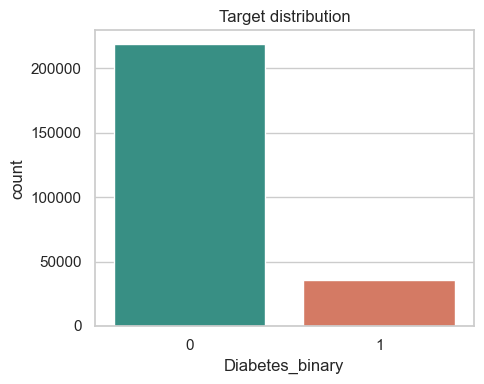

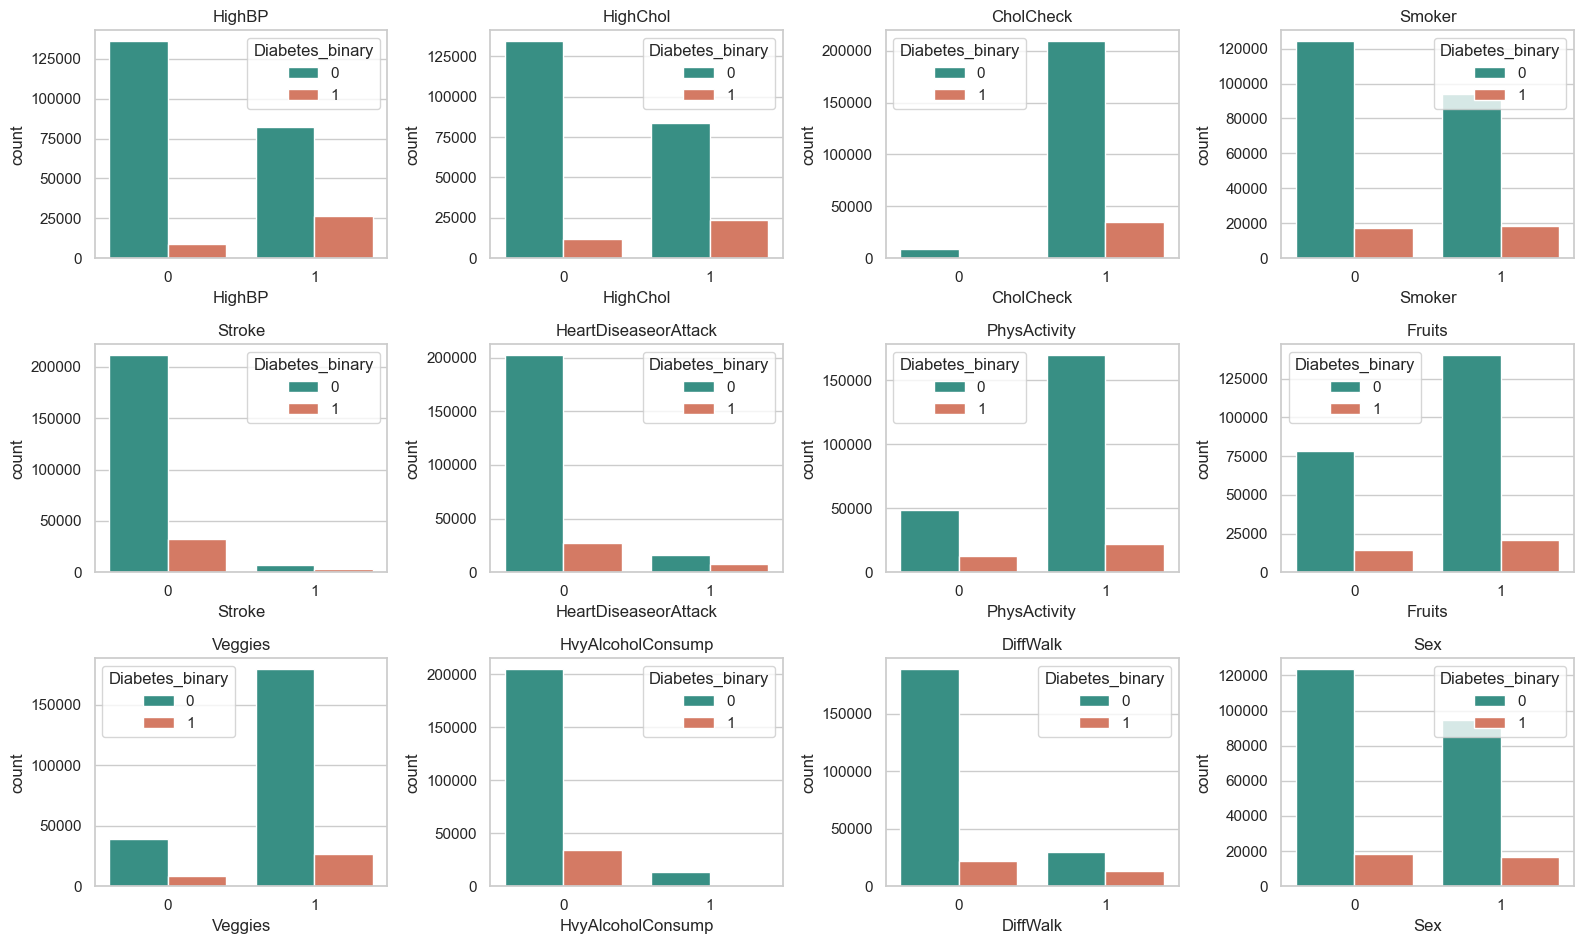

In [6]:
target_counts = eda_df[target].value_counts(dropna=False).rename_axis(target).reset_index(name="count")
target_counts["share"] = target_counts["count"] / len(eda_df)
display(target_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=eda_df, x=target, hue=target, palette=target_palette, legend=False, ax=ax)
ax.set_title("Target distribution")
plt.tight_layout()
plt.show()

if binary_features:
    n_cols = 4
    n_rows = int(np.ceil(len(binary_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, binary_features):
        sns.countplot(data=eda_df, x=col, hue=target, palette=target_palette, ax=ax)
        ax.set_title(col)
    for ax in axes[len(binary_features):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

,feature,value,count,diabetes_rate
0,HighBP,0,144851,0.060
1,HighBP,1,108829,0.244
2,HighChol,0,146089,0.080
3,HighChol,1,107591,0.220
4,CholCheck,0,9470,0.025
...,...,...,...,...
183,Age,9,33244,0.172
184,Age,10,32194,0.204
185,Age,11,23533,0.218
186,Age,12,15980,0.213


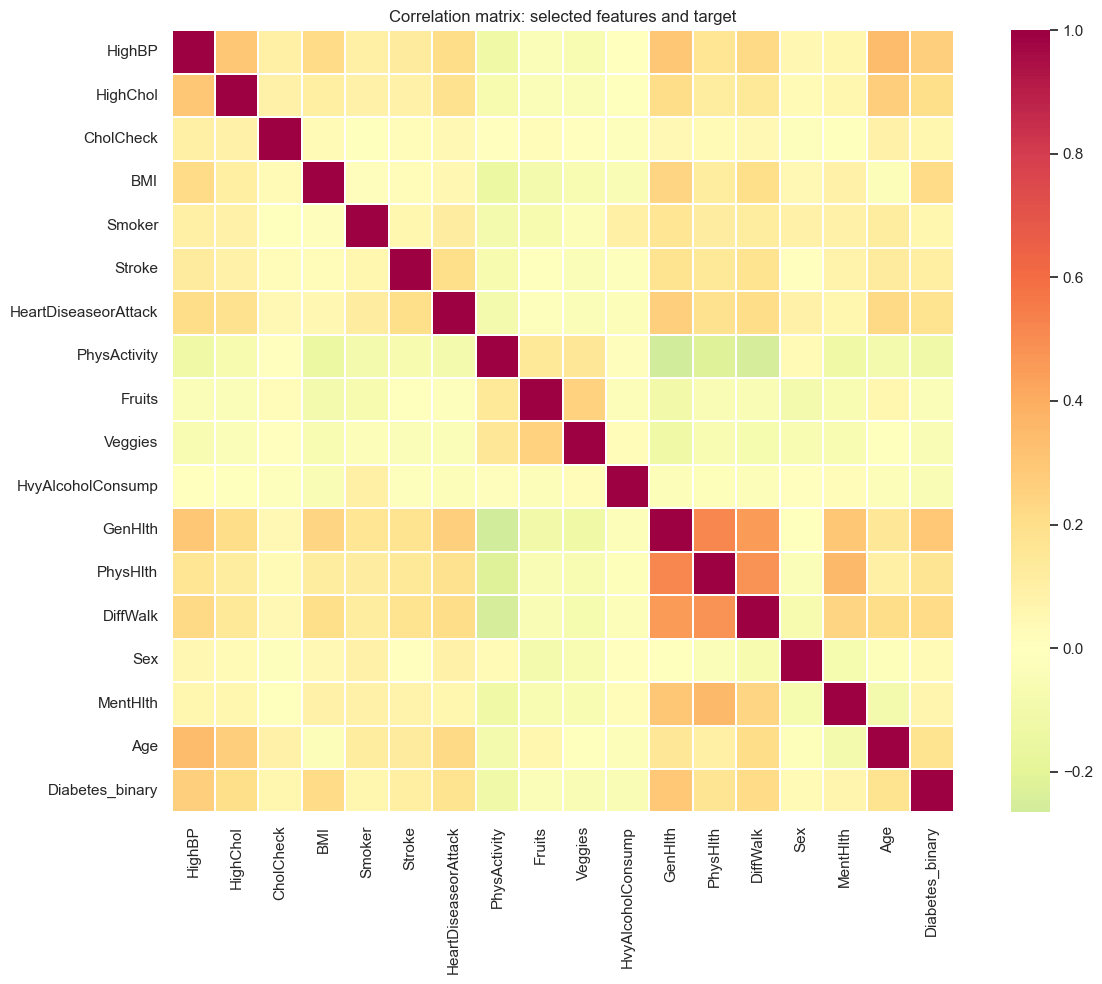

,correlation_with_target
GenHlth,0.294
HighBP,0.263
DiffWalk,0.218
BMI,0.217
HighChol,0.200
Age,0.177
HeartDiseaseorAttack,0.177
PhysHlth,0.171
PhysActivity,-0.118
Stroke,0.106


In [7]:
rate_tables = []
for col in selected_features:
    tmp = eda_df.groupby(col, dropna=False)[target].agg(count="size", diabetes_rate="mean").reset_index()
    tmp = tmp.rename(columns={col: "value"})
    tmp.insert(0, "feature", col)
    rate_tables.append(tmp)
feature_target_rates = pd.concat(rate_tables, ignore_index=True)
display(feature_target_rates)

corr = eda_df[selected_features + [target]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap=heatmap_palette, center=0, annot=False, square=True, linewidths=0.3, ax=ax)
ax.set_title("Correlation matrix: selected features and target")
plt.tight_layout()
plt.show()

target_corr = corr[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False).to_frame("correlation_with_target")
display(target_corr)

In [8]:
# Primary metric configuration for all model comparisons.
primary_metric = "f1_5"
metric_beta = 1.5
metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "f1_5", "roc_auc", "pr_auc"]


**Metric Choice**

For this diabetes screening task, missing positive cases is more costly than raising some false alarms, but precision should not be ignored. `F1.5` is used as the primary metric for feature selection, Optuna tuning, model comparison, and blending because it gives extra weight to recall without being as aggressive as `F2`. `PR AUC` is kept as the main ranking metric for imbalanced probabilities, while `ROC AUC` is treated as a secondary diagnostic metric.


In [9]:
X_model_full = eda_df[selected_features].copy()
y_model = eda_df[target].astype(int).copy()


X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_model_full, y_model, test_size=0.2, random_state=42, stratify=y_model
)

split_summary = pd.DataFrame({
    "part": ["modeling_sample", "train_full", "test_full"],
    "rows": [len(X_model_full), len(X_train_full), len(X_test_full)],
    "positive_share": [y_model.mean(), y_train.mean(), y_test.mean()],
    "duplicate_rows_kept": [
        pd.concat([X_model_full, y_model.rename(target)], axis=1).duplicated().sum(),
        pd.concat([X_train_full, y_train.rename(target)], axis=1).duplicated().sum(),
        pd.concat([X_test_full, y_test.rename(target)], axis=1).duplicated().sum(),
    ],
})
display(split_summary)

,part,rows,positive_share,duplicate_rows_kept
0,modeling_sample,253680,0.139,65225
1,train_full,202944,0.139,48333
2,test_full,50736,0.139,6658


In [10]:
feature_metric_rows = []
for col in selected_features:
    raw_score = X_train_full[col].to_numpy()
    roc_auc = roc_auc_score(y_train, raw_score)
    directional_score = -raw_score if roc_auc < 0.5 else raw_score
    direction = "lower_values_increase_risk" if roc_auc < 0.5 else "higher_values_increase_risk"
    unique_values = np.sort(pd.Series(raw_score).dropna().unique())
    threshold = 0.5 if len(unique_values) == 2 and set(unique_values).issubset({0, 1}) and roc_auc >= 0.5 else np.median(directional_score)
    y_single_pred = (directional_score >= threshold).astype(int)
    feature_metric_rows.append({
        "feature": col,
        "individual_roc_auc": roc_auc,
        "individual_roc_auc_strength": max(roc_auc, 1 - roc_auc),
        "individual_pr_auc": average_precision_score(y_train, directional_score),
        "individual_f2": fbeta_score(y_train, y_single_pred, beta=2, zero_division=0),
        "individual_recall": recall_score(y_train, y_single_pred, zero_division=0),
        "direction": direction,
    })

feature_scores_df = pd.DataFrame(feature_metric_rows).sort_values(
    ["individual_roc_auc_strength", "individual_pr_auc"], ascending=False
).reset_index(drop=True)
display(feature_scores_df)

correlation_threshold = 0.65
feature_strength = feature_scores_df.set_index("feature")["individual_roc_auc_strength"].to_dict()
train_corr_abs = X_train_full[selected_features].corr().abs()
features_to_drop = set()
correlation_decisions = []

ordered_features = feature_scores_df["feature"].tolist()
for i, feature_a in enumerate(ordered_features):
    if feature_a in features_to_drop:
        continue
    for feature_b in ordered_features[i + 1:]:
        if feature_b in features_to_drop:
            continue
        corr_value = train_corr_abs.loc[feature_a, feature_b]
        if corr_value > correlation_threshold:
            keep_feature, drop_feature = (feature_a, feature_b) if feature_strength[feature_a] >= feature_strength[feature_b] else (feature_b, feature_a)
            features_to_drop.add(drop_feature)
            correlation_decisions.append({
                "feature_a": feature_a,
                "feature_b": feature_b,
                "abs_corr": corr_value,
                "kept": keep_feature,
                "dropped": drop_feature,
                "kept_auc_strength": feature_strength[keep_feature],
                "dropped_auc_strength": feature_strength[drop_feature],
            })

corr_pruned_features = [col for col in selected_features if col not in features_to_drop]
correlation_decisions_df = pd.DataFrame(correlation_decisions)
display(correlation_decisions_df)

,feature,individual_roc_auc,individual_roc_auc_strength,individual_pr_auc,individual_f2,individual_recall,direction
0,GenHlth,0.731,0.731,0.263,0.489,0.968,higher_values_increase_risk
1,BMI,0.690,0.690,0.248,0.488,0.787,higher_values_increase_risk
2,HighBP,0.688,0.688,0.219,0.532,0.753,higher_values_increase_risk
3,Age,0.647,0.647,0.191,0.480,0.800,higher_values_increase_risk
4,HighChol,0.643,0.643,0.194,0.476,0.671,higher_values_increase_risk
5,DiffWalk,0.619,0.619,0.202,0.358,0.372,higher_values_increase_risk
6,PhysHlth,0.614,0.614,0.205,0.447,1.000,higher_values_increase_risk
7,HeartDiseaseorAttack,0.575,0.575,0.182,0.239,0.224,higher_values_increase_risk
8,PhysActivity,0.427,0.573,0.166,0.447,1.000,lower_values_increase_risk
9,Smoker,0.544,0.544,0.152,0.361,0.519,higher_values_increase_risk


""


In [11]:
fs_metric = primary_metric
fs_min_improvement = 0.001
fs_min_features = min(2, len(corr_pruned_features))

X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
    X_train_full[corr_pruned_features], y_train, test_size=0.25, random_state=42, stratify=y_train
)

candidate_order = feature_scores_df[feature_scores_df["feature"].isin(corr_pruned_features)]["feature"].tolist()
selected_forward_features = []
remaining_features = candidate_order.copy()
forward_rows = []
best_metric_value = -np.inf

while remaining_features:
    trial_rows = []
    for candidate in remaining_features:
        trial_features = selected_forward_features + [candidate]
        selector_model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
        ])
        selector_model.fit(X_fs_train[trial_features], y_fs_train)
        val_score = selector_model.predict_proba(X_fs_val[trial_features])[:, 1]
        val_pred = (val_score >= 0.5).astype(int)
        trial_rows.append({
            "candidate": candidate,
            "features": trial_features,
            "pr_auc": average_precision_score(y_fs_val, val_score),
            "roc_auc": roc_auc_score(y_fs_val, val_score),
            "f1_5": fbeta_score(y_fs_val, val_pred, beta=metric_beta, zero_division=0),
            "f2": fbeta_score(y_fs_val, val_pred, beta=2, zero_division=0),
            "recall": recall_score(y_fs_val, val_pred, zero_division=0),
        })
    trial_df = pd.DataFrame(trial_rows).sort_values(fs_metric, ascending=False)
    best_trial = trial_df.iloc[0]
    improvement = best_trial[fs_metric] - best_metric_value
    if improvement < fs_min_improvement and len(selected_forward_features) >= fs_min_features:
        break
    selected_forward_features = best_trial["features"]
    remaining_features.remove(best_trial["candidate"])
    best_metric_value = best_trial[fs_metric]
    forward_rows.append({
        "step": len(selected_forward_features),
        "added_feature": best_trial["candidate"],
        "n_features": len(selected_forward_features),
        "validation_f1_5": best_trial["f1_5"],
        "validation_pr_auc": best_trial["pr_auc"],
        "validation_roc_auc": best_trial["roc_auc"],
        "validation_f2": best_trial["f2"],
        "validation_recall": best_trial["recall"],
    })

forward_selection_df = pd.DataFrame(forward_rows)
modeling_features = selected_forward_features if selected_forward_features else corr_pruned_features
X_model = X_model_full[modeling_features].copy()
X_train = X_train_full[modeling_features].copy()
X_test = X_test_full[modeling_features].copy()

model_feature_dictionary = (
    variables.loc[
        variables["name"].isin(modeling_features),
        ["name", "role", "type", "demographic", "description", "missing_values"],
    ]
    .merge(feature_scores_df, left_on="name", right_on="feature", how="left")
    .drop(columns="feature")
)
model_feature_dictionary.insert(
    1,
    "modeling_order",
    model_feature_dictionary["name"].map({feature: idx + 1 for idx, feature in enumerate(modeling_features)}),
)
model_feature_dictionary = model_feature_dictionary.sort_values("modeling_order").reset_index(drop=True)

print(f"Modeling features: {len(modeling_features)}")
print(modeling_features)
display(forward_selection_df)
display(model_feature_dictionary)


Modeling features: 8
['HighBP', 'GenHlth', 'BMI', 'Age', 'HvyAlcoholConsump', 'HeartDiseaseorAttack', 'HighChol', 'DiffWalk']


,step,added_feature,n_features,validation_f1_5,validation_pr_auc,validation_roc_auc,validation_f2,validation_recall
0,1,HighBP,1,0.459,0.219,0.688,0.532,0.752
1,2,GenHlth,2,0.489,0.320,0.777,0.544,0.688
2,3,BMI,3,0.500,0.364,0.794,0.562,0.729
3,4,Age,4,0.518,0.377,0.809,0.583,0.757
4,5,HvyAlcoholConsump,5,0.520,0.380,0.811,0.585,0.759
5,6,HeartDiseaseorAttack,6,0.523,0.383,0.813,0.587,0.760
6,7,HighChol,7,0.526,0.395,0.818,0.589,0.760
7,8,DiffWalk,8,0.527,0.395,0.818,0.590,0.761


,name,modeling_order,role,type,demographic,description,missing_values,individual_roc_auc,individual_roc_auc_strength,individual_pr_auc,individual_f2,individual_recall,direction
0,HighBP,1,Feature,Binary,NaN,0 = no high BP 1 = high BP,no,0.688,0.688,0.219,0.532,0.753,higher_values_increase_risk
1,GenHlth,2,Feature,Integer,NaN,Would you say that in general your health is: ...,no,0.731,0.731,0.263,0.489,0.968,higher_values_increase_risk
2,BMI,3,Feature,Integer,NaN,Body Mass Index,no,0.690,0.690,0.248,0.488,0.787,higher_values_increase_risk
3,Age,4,Feature,Integer,Age,13-level age category (_AGEG5YR see codebook) ...,no,0.647,0.647,0.191,0.480,0.800,higher_values_increase_risk
4,HvyAlcoholConsump,5,Feature,Binary,NaN,Heavy drinkers (adult men having more than 14 ...,no,0.481,0.519,0.144,0.453,0.977,lower_values_increase_risk
5,HeartDiseaseorAttack,6,Feature,Binary,NaN,coronary heart disease (CHD) or myocardial inf...,no,0.575,0.575,0.182,0.239,0.224,higher_values_increase_risk
6,HighChol,7,Feature,Binary,NaN,0 = no high cholesterol 1 = high cholesterol,no,0.643,0.643,0.194,0.476,0.671,higher_values_increase_risk
7,DiffWalk,8,Feature,Binary,NaN,Do you have serious difficulty walking or clim...,no,0.619,0.619,0.202,0.358,0.372,higher_values_increase_risk


In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=100, class_weight="balanced", random_state=42),
    "Naive Bayes": GaussianNB(),
    "k-NN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1))]),
    "Linear SVM": Pipeline([("scaler", StandardScaler()), ("model", LinearSVC(class_weight="balanced", dual="auto", max_iter=10000, tol=1e-3, random_state=42))]),
}

model_results = []
fitted_models = {}
predictions = {}

for name, estimator in models.items():
    fitted = clone(estimator)
    fitted.fit(X_train, y_train)
    y_pred = fitted.predict(X_test)
    if hasattr(fitted, "predict_proba"):
        y_score = fitted.predict_proba(X_test)[:, 1]
    elif hasattr(fitted, "decision_function"):
        y_score = fitted.decision_function(X_test)
    else:
        y_score = y_pred

    fitted_models[name] = fitted
    predictions[name] = {"pred": y_pred, "score": y_score}
    model_results.append({
        "model": name,
        "train_rows": len(X_train),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f1_5": fbeta_score(y_test, y_pred, beta=metric_beta, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    })

results_df = pd.DataFrame(model_results).sort_values(primary_metric, ascending=False).reset_index(drop=True)
display(results_df)


,model,train_rows,accuracy,balanced_accuracy,precision,recall,f1,f1_5,roc_auc,pr_auc
0,Logistic Regression,202944,0.729,0.741,0.308,0.757,0.438,0.523,0.816,0.387
1,Linear SVM,202944,0.725,0.740,0.305,0.761,0.435,0.521,0.815,0.388
2,Decision Tree,202944,0.722,0.736,0.302,0.755,0.431,0.516,0.809,0.381
3,Naive Bayes,202944,0.803,0.674,0.353,0.496,0.412,0.441,0.791,0.354
4,k-NN,202944,0.858,0.570,0.472,0.170,0.250,0.212,0.759,0.331


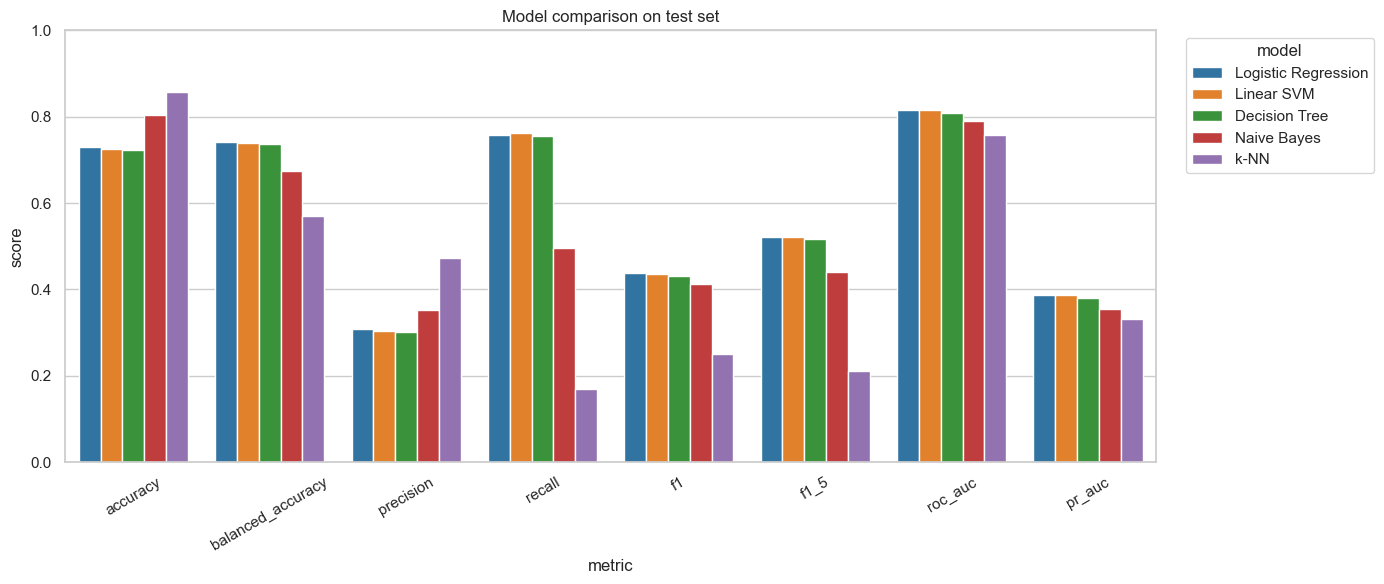

Best model by F1.5: Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     43667
           1       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736



In [13]:
metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "f1_5", "roc_auc", "pr_auc"]
results_long = results_df.melt(id_vars="model", value_vars=metric_cols, var_name="metric", value_name="score")

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=results_long, x="metric", y="score", hue="model", palette="tab10", ax=ax)
ax.set_title("Model comparison on test set")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["model"]
print(f"Best model by F1.5: {best_model_name}")
print(classification_report(y_test, predictions[best_model_name]["pred"], zero_division=0))

,feature,coefficient_scaled,odds_ratio_per_1_sd
0,GenHlth,0.627,1.873
1,BMI,0.496,1.643
2,Age,0.479,1.614
3,HighBP,0.385,1.469
4,HighChol,0.290,1.336
5,HvyAlcoholConsump,-0.176,0.839
6,HeartDiseaseorAttack,0.094,1.099
7,DiffWalk,0.035,1.036


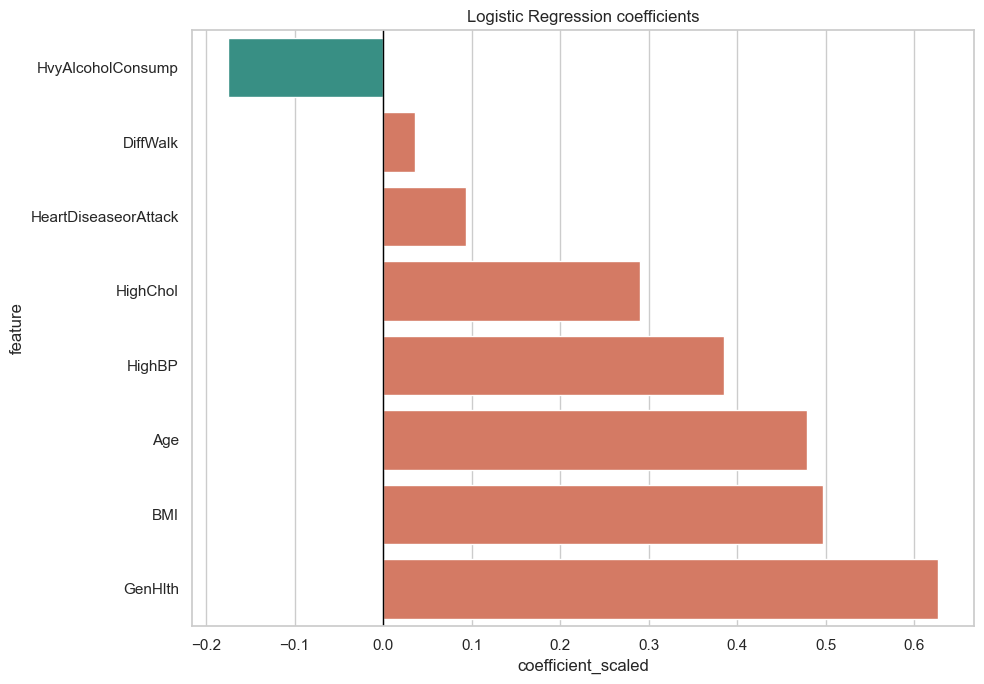

In [14]:
log_reg = fitted_models["Logistic Regression"]
log_reg_model = log_reg.named_steps["model"]
coef_df = pd.DataFrame({"feature": modeling_features, "coefficient_scaled": log_reg_model.coef_[0]})
coef_df["odds_ratio_per_1_sd"] = np.exp(coef_df["coefficient_scaled"])
coef_df["abs_coefficient"] = coef_df["coefficient_scaled"].abs()
coef_df["direction"] = np.where(coef_df["coefficient_scaled"] < 0, "negative", "positive")
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
display(coef_df[["feature", "coefficient_scaled", "odds_ratio_per_1_sd"]])

fig, ax = plt.subplots(figsize=(10, 7))
coef_plot = coef_df.sort_values("coefficient_scaled")
sns.barplot(
    data=coef_plot, x="coefficient_scaled", y="feature", hue="direction",
    palette={"negative": "#2a9d8f", "positive": "#e76f51"},
    dodge=False, legend=False, ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Logistic Regression coefficients")
plt.tight_layout()
plt.show()

In [15]:
# For CatBoost all selected survey variables except BMI are categorical/ordinal buckets.
# BMI remains the only truly continuous numeric feature in the selected set.
catboost_cat_features = [col for col in modeling_features if col != "BMI"]

advanced_models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=50, class_weight="balanced_subsample", n_jobs=-1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=250, learning_rate=0.06, max_leaf_nodes=31, l2_regularization=0.1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, eval_metric="logloss", tree_method="hist", random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=-1, num_leaves=31, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, depth=5, learning_rate=0.05, loss_function="Logloss", eval_metric="F1", cat_features=catboost_cat_features, one_hot_max_size=32, auto_class_weights="Balanced", random_seed=42, verbose=False),
}
list(advanced_models.keys())


['Random Forest', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']

In [16]:
advanced_results = []
advanced_fitted_models = {}
advanced_predictions = {}

for name, estimator in advanced_models.items():
    fitted = copy.deepcopy(estimator)
    fitted.fit(X_train, y_train)
    y_pred = fitted.predict(X_test)
    y_score = fitted.predict_proba(X_test)[:, 1] if hasattr(fitted, "predict_proba") else y_pred
    advanced_fitted_models[name] = fitted
    advanced_predictions[name] = {"pred": y_pred, "score": y_score}
    advanced_results.append({
        "model": name,
        "train_rows": len(X_train),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f1_5": fbeta_score(y_test, y_pred, beta=metric_beta, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    })

advanced_results_df = pd.DataFrame(advanced_results).sort_values(primary_metric, ascending=False).reset_index(drop=True)
display(advanced_results_df)

,model,train_rows,accuracy,balanced_accuracy,precision,recall,f1,f1_5,roc_auc,pr_auc
0,CatBoost,202944,0.719,0.746,0.303,0.783,0.437,0.527,0.822,0.416
1,LightGBM,202944,0.716,0.746,0.301,0.786,0.436,0.526,0.822,0.415
2,Random Forest,202944,0.721,0.745,0.304,0.778,0.437,0.526,0.821,0.415
3,XGBoost,202944,0.865,0.566,0.556,0.151,0.237,0.194,0.823,0.415
4,HistGradientBoosting,202944,0.865,0.563,0.561,0.145,0.231,0.188,0.822,0.416


In [17]:
X_train_inner, X_val, y_train_inner, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
optuna_n_trials = 20
neg_pos_ratio = (y_train_inner == 0).sum() / max((y_train_inner == 1).sum(), 1)


def make_advanced_estimator(model_name, trial):
    if model_name == "Random Forest":
        return RandomForestClassifier(n_estimators=trial.suggest_int("n_estimators", 120, 600, step=60), max_depth=trial.suggest_int("max_depth", 5, 18), min_samples_leaf=trial.suggest_int("min_samples_leaf", 20, 200, step=20), max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]), class_weight="balanced_subsample", n_jobs=-1, random_state=42)
    if model_name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(max_iter=trial.suggest_int("max_iter", 100, 450, step=50), learning_rate=trial.suggest_float("learning_rate", 0.02, 0.16, log=True), max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 15, 63, step=8), min_samples_leaf=trial.suggest_int("min_samples_leaf", 20, 180, step=20), l2_regularization=trial.suggest_float("l2_regularization", 1e-4, 2.0, log=True), random_state=42)
    if model_name == "XGBoost":
        return XGBClassifier(n_estimators=trial.suggest_int("n_estimators", 120, 420, step=60), max_depth=trial.suggest_int("max_depth", 2, 8), learning_rate=trial.suggest_float("learning_rate", 0.02, 0.18, log=True), subsample=trial.suggest_float("subsample", 0.65, 1.0), colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0), min_child_weight=trial.suggest_float("min_child_weight", 1.0, 12.0), reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True), scale_pos_weight=neg_pos_ratio, eval_metric="logloss", tree_method="hist", random_state=42, n_jobs=-1)
    if model_name == "LightGBM":
        return LGBMClassifier(n_estimators=trial.suggest_int("n_estimators", 120, 420, step=60), num_leaves=trial.suggest_int("num_leaves", 15, 63), learning_rate=trial.suggest_float("learning_rate", 0.02, 0.18, log=True), min_child_samples=trial.suggest_int("min_child_samples", 20, 180, step=20), subsample=trial.suggest_float("subsample", 0.65, 1.0), colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0), reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True), class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
    if model_name == "CatBoost":
        return CatBoostClassifier(iterations=trial.suggest_int("iterations", 120, 600, step=60), depth=trial.suggest_int("depth", 3, 8), learning_rate=trial.suggest_float("learning_rate", 0.02, 0.18, log=True), l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 12.0), random_strength=trial.suggest_float("random_strength", 0.1, 10.0, log=True), bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0), border_count=trial.suggest_int("border_count", 32, 128, step=32), loss_function="Logloss", eval_metric="F1", cat_features=catboost_cat_features, one_hot_max_size=32, auto_class_weights="Balanced", random_seed=42, verbose=False)
    raise ValueError(f"Unknown model: {model_name}")


def objective_factory(model_name):
    def objective(trial):
        estimator = make_advanced_estimator(model_name, trial)
        estimator.fit(X_train_inner, y_train_inner)
        y_val_pred = estimator.predict(X_val)
        return fbeta_score(y_val, y_val_pred, beta=metric_beta, zero_division=0)
    return objective


tuning_studies = {}
tuning_rows = []
for model_name in advanced_models.keys():
    study = optuna.create_study(direction="maximize", study_name=f"{model_name} tuning")
    study.optimize(objective_factory(model_name), n_trials=optuna_n_trials, show_progress_bar=False)
    tuning_studies[model_name] = study
    tuning_rows.append({"model": model_name, "best_validation_f1_5": study.best_value, "best_params": study.best_params})
tuning_results_df = pd.DataFrame(tuning_rows).sort_values("best_validation_f1_5", ascending=False)
display(tuning_results_df)


,model,best_validation_f1_5,best_params
2,XGBoost,0.528,"{'n_estimators': 300, 'max_depth': 6, 'learnin..."
4,CatBoost,0.528,"{'iterations': 240, 'depth': 3, 'learning_rate..."
3,LightGBM,0.528,"{'n_estimators': 360, 'num_leaves': 42, 'learn..."
0,Random Forest,0.527,"{'n_estimators': 540, 'max_depth': 15, 'min_sa..."
1,HistGradientBoosting,0.203,"{'max_iter': 450, 'learning_rate': 0.144237768..."


In [18]:
tuned_advanced_results = []
tuned_advanced_fitted_models = {}
tuned_advanced_predictions = {}

for model_name, study in tuning_studies.items():
    fixed_trial = optuna.trial.FixedTrial(study.best_params)
    fitted = make_advanced_estimator(model_name, fixed_trial)
    fitted.fit(X_train, y_train)
    y_pred = fitted.predict(X_test)
    y_score = fitted.predict_proba(X_test)[:, 1] if hasattr(fitted, "predict_proba") else y_pred
    tuned_name = f"{model_name} tuned"
    tuned_advanced_fitted_models[tuned_name] = fitted
    tuned_advanced_predictions[tuned_name] = {"pred": y_pred, "score": y_score}
    tuned_advanced_results.append({
        "model": tuned_name,
        "train_rows": len(X_train),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f1_5": fbeta_score(y_test, y_pred, beta=metric_beta, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    })

tuned_advanced_results_df = pd.DataFrame(tuned_advanced_results).sort_values(primary_metric, ascending=False).reset_index(drop=True)
display(tuned_advanced_results_df)

,model,train_rows,accuracy,balanced_accuracy,precision,recall,f1,f1_5,roc_auc,pr_auc
0,LightGBM tuned,202944,0.717,0.745,0.302,0.785,0.436,0.526,0.822,0.416
1,XGBoost tuned,202944,0.717,0.745,0.302,0.784,0.436,0.526,0.822,0.417
2,Random Forest tuned,202944,0.721,0.745,0.304,0.777,0.437,0.525,0.821,0.415
3,CatBoost tuned,202944,0.723,0.744,0.305,0.773,0.437,0.525,0.820,0.411
4,HistGradientBoosting tuned,202944,0.865,0.566,0.553,0.151,0.237,0.194,0.822,0.415


In [19]:
# Exhaustive blends over all tuned advanced models plus Logistic Regression.
# We average positive-class probabilities and try every combination of size 2..N.
# The threshold is selected by F1.5, because recall is more important for diabetes.
blend_beta = 1.5


def get_positive_score(model, X_values):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_values)[:, 1]
    if hasattr(model, "decision_function"):
        raw_score = model.decision_function(X_values)
        raw_score = np.asarray(raw_score, dtype=float)
        score_min, score_max = raw_score.min(), raw_score.max()
        if score_max > score_min:
            return (raw_score - score_min) / (score_max - score_min)
        return np.full_like(raw_score, fill_value=0.5, dtype=float)
    return model.predict(X_values)


blend_candidate_models = {"Logistic Regression": fitted_models["Logistic Regression"]}
blend_candidate_models.update(tuned_advanced_fitted_models)

blend_results = []
blend_predictions = {}
threshold_grid = np.linspace(0.15, 0.85, 71)
model_names = list(blend_candidate_models.keys())

for combo_size in range(2, len(model_names) + 1):
    for combo_names in combinations(model_names, combo_size):
        score_columns = []
        for model_name in combo_names:
            score_columns.append(get_positive_score(blend_candidate_models[model_name], X_test))

        blend_score = np.mean(np.column_stack(score_columns), axis=1)
        threshold_scores = []
        for threshold in threshold_grid:
            candidate_pred = (blend_score >= threshold).astype(int)
            threshold_scores.append(fbeta_score(y_test, candidate_pred, beta=blend_beta, zero_division=0))

        best_threshold = threshold_grid[int(np.argmax(threshold_scores))]
        y_pred = (blend_score >= best_threshold).astype(int)
        blend_name = " + ".join(combo_names)

        blend_predictions[blend_name] = {
            "pred": y_pred,
            "score": blend_score,
            "models": list(combo_names),
            "threshold": best_threshold,
        }
        blend_results.append({
            "model": blend_name,
            "train_rows": len(X_train),
            "n_blended_models": combo_size,
            "threshold": best_threshold,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "f1_5": fbeta_score(y_test, y_pred, beta=blend_beta, zero_division=0),
            "roc_auc": roc_auc_score(y_test, blend_score),
            "pr_auc": average_precision_score(y_test, blend_score),
        })

blend_results_df = pd.DataFrame(blend_results).sort_values(["f1_5", "pr_auc"], ascending=False).reset_index(drop=True)

In [20]:
pd.set_option("display.max_colwidth", None)
display(blend_results_df.head(5))

,model,train_rows,n_blended_models,threshold,accuracy,balanced_accuracy,precision,recall,f1,f1_5,roc_auc,pr_auc
0,Logistic Regression + Random Forest tuned + XGBoost tuned + LightGBM tuned,202944,4,0.540,0.748,0.746,0.324,0.742,0.451,0.531,0.822,0.415
1,XGBoost tuned + LightGBM tuned + CatBoost tuned,202944,3,0.540,0.747,0.746,0.323,0.744,0.451,0.531,0.822,0.416
2,Logistic Regression + Random Forest tuned + XGBoost tuned + LightGBM tuned + CatBoost tuned,202944,5,0.540,0.749,0.746,0.324,0.741,0.451,0.531,0.822,0.415
3,Random Forest tuned + HistGradientBoosting tuned + XGBoost tuned + CatBoost tuned,202944,4,0.450,0.752,0.745,0.327,0.735,0.453,0.531,0.822,0.417
4,Logistic Regression + Random Forest tuned + HistGradientBoosting tuned + XGBoost tuned + LightGBM tuned + CatBoost tuned,202944,6,0.480,0.750,0.745,0.325,0.739,0.452,0.531,0.822,0.416


,model,train_rows,accuracy,balanced_accuracy,precision,recall,f1,f1_5,roc_auc,pr_auc,model_group,n_blended_models,threshold
0,Logistic Regression + Random Forest tuned + XGBoost tuned + LightGBM tuned,202944,0.748,0.746,0.324,0.742,0.451,0.531,0.822,0.415,Blend combinations,4.000,0.540
1,XGBoost tuned + LightGBM tuned + CatBoost tuned,202944,0.747,0.746,0.323,0.744,0.451,0.531,0.822,0.416,Blend combinations,3.000,0.540
2,Logistic Regression + Random Forest tuned + XGBoost tuned + LightGBM tuned + CatBoost tuned,202944,0.749,0.746,0.324,0.741,0.451,0.531,0.822,0.415,Blend combinations,5.000,0.540
3,Random Forest tuned + HistGradientBoosting tuned + XGBoost tuned + CatBoost tuned,202944,0.752,0.745,0.327,0.735,0.453,0.531,0.822,0.417,Blend combinations,4.000,0.450
4,Logistic Regression + Random Forest tuned + HistGradientBoosting tuned + XGBoost tuned + LightGBM tuned + CatBoost tuned,202944,0.750,0.745,0.325,0.739,0.452,0.531,0.822,0.416,Blend combinations,6.000,0.480
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,Linear SVM,202944,0.725,0.740,0.305,0.761,0.435,0.521,0.815,0.388,Simple,NaN,NaN
63,Decision Tree,202944,0.722,0.736,0.302,0.755,0.431,0.516,0.809,0.381,Simple,NaN,NaN
64,Naive Bayes,202944,0.803,0.674,0.353,0.496,0.412,0.441,0.791,0.354,Simple,NaN,NaN
65,k-NN,202944,0.858,0.570,0.472,0.170,0.250,0.212,0.759,0.331,Simple,NaN,NaN


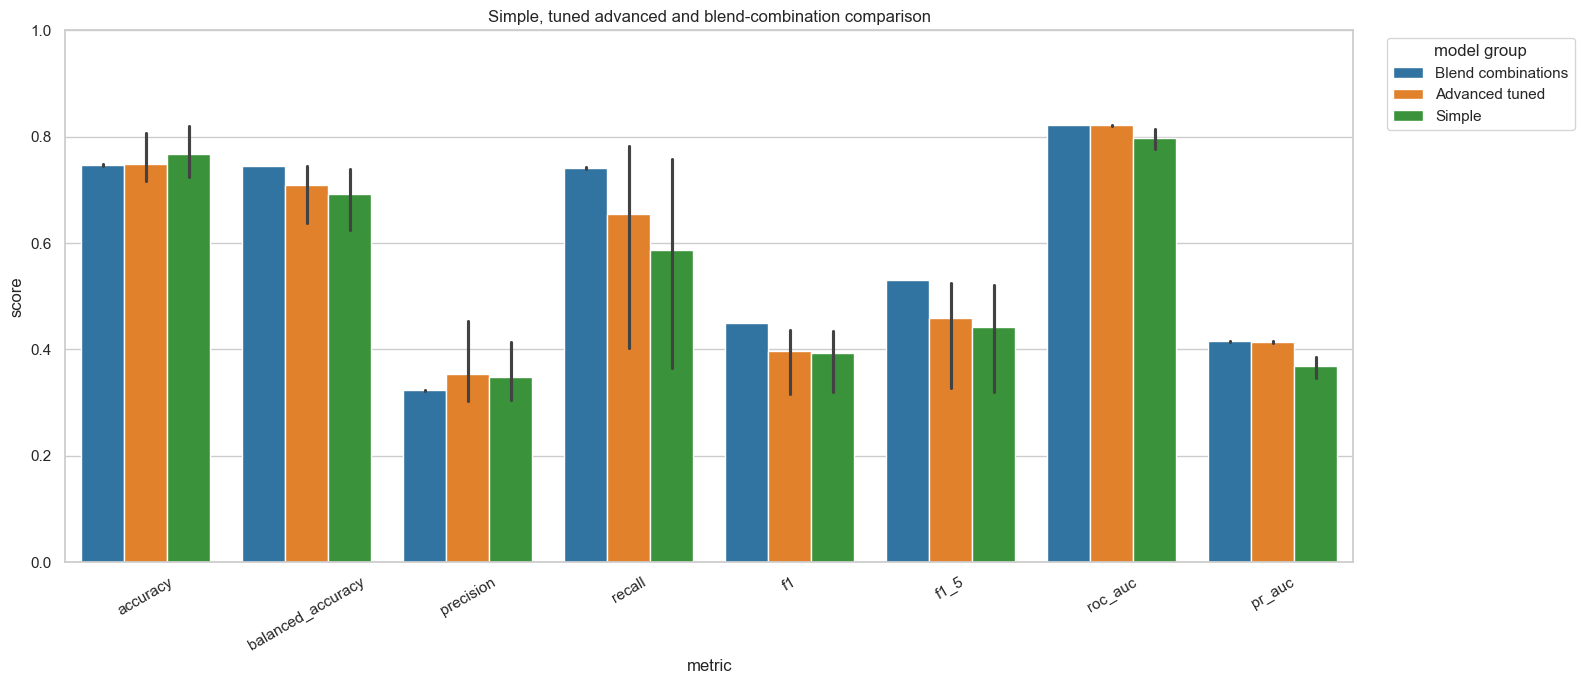

Best overall model by F1.5: Logistic Regression + Random Forest tuned + XGBoost tuned + LightGBM tuned


In [21]:
simple_results_for_compare = results_df.copy()
simple_results_for_compare["model_group"] = "Simple"
tuned_results_for_compare = tuned_advanced_results_df.copy()
tuned_results_for_compare["model_group"] = "Advanced tuned"
blend_results_for_compare = blend_results_df.copy()
blend_results_for_compare["model_group"] = "Blend combinations"

# Advanced baseline models are intentionally excluded from the final comparison.
all_results_df = pd.concat(
    [simple_results_for_compare, tuned_results_for_compare, blend_results_for_compare],
    ignore_index=True,
).sort_values(primary_metric, ascending=False).reset_index(drop=True)
display(all_results_df)

all_results_long = all_results_df.melt(id_vars=["model", "model_group"], value_vars=metric_cols, var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(16, 7))
sns.barplot(data=all_results_long, x="metric", y="score", hue="model_group", palette="tab10", ax=ax)
ax.set_title("Simple, tuned advanced and blend-combination comparison")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="model group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
print(f"Best overall model by F1.5: {all_results_df.iloc[0]['model']}")

In [ ]:
# Per-observation SHAP cache.
# Saves one long CSV per model/blend: observation_id, model, feature, feature_value, shap_value.
shap_dir = Path("data") / "shap"
shap_dir.mkdir(parents=True, exist_ok=True)

# Use the full training split so every modeled training observation has cached SHAP values.
X_shap = X_train.copy()
observation_ids = X_shap.index.to_numpy()

advanced_for_shap = {}
advanced_for_shap.update(tuned_advanced_fitted_models)

# Best tuned models plus all tree components that appear in the best blend.
best_blend_name = blend_results_df.iloc[0]["model"] if "blend_results_df" in globals() and not blend_results_df.empty else None
best_blend_components = blend_predictions[best_blend_name]["models"] if best_blend_name else []

shap_candidate_names = (
    all_results_df[all_results_df["model"].isin(advanced_for_shap.keys())]
    .sort_values(primary_metric, ascending=False)
    .head(3)["model"]
    .tolist()
)
for component_name in best_blend_components:
    if component_name in advanced_for_shap and component_name not in shap_candidate_names:
        shap_candidate_names.append(component_name)


def safe_file_name(name):
    return (
        name.replace(" ", "_")
        .replace("/", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
    )


def compute_tree_shap_values(fitted, X_values):
    try:
        explainer = shap.TreeExplainer(fitted)
        shap_values = explainer.shap_values(X_values)
        if isinstance(shap_values, list):
            shap_values = shap_values[-1]
        shap_values = np.asarray(shap_values)
        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, -1]
        return shap_values
    except Exception:
        if fitted.__class__.__name__ == "CatBoostClassifier":
            pool = Pool(X_values, cat_features=catboost_cat_features)
            shap_values = fitted.get_feature_importance(pool, type="ShapValues")
            return np.asarray(shap_values)[:, :-1]
        raise


def save_observation_shap(model_name, shap_values, X_values, cache_path, shap_kind="exact"):
    shap_long = pd.DataFrame(shap_values, columns=X_values.columns)
    shap_long.insert(0, "observation_id", observation_ids)
    shap_long = shap_long.melt(
        id_vars="observation_id",
        var_name="feature",
        value_name="shap_value",
    )

    feature_values = X_values.copy()
    feature_values.insert(0, "observation_id", observation_ids)
    feature_values = feature_values.melt(
        id_vars="observation_id",
        var_name="feature",
        value_name="feature_value",
    )

    shap_long = shap_long.merge(feature_values, on=["observation_id", "feature"], how="left")
    shap_long.insert(1, "model", model_name)
    shap_long.insert(2, "shap_kind", shap_kind)
    shap_long.to_csv(cache_path, index=False)
    return shap_long


shap_long_frames = []
shap_summary_frames = []
model_shap_values = {}

for model_name in shap_candidate_names:
    cache_path = shap_dir / f"{safe_file_name(model_name)}_observation_shap.csv"
    summary_path = shap_dir / f"{safe_file_name(model_name)}_mean_abs_shap.csv"
    if cache_path.exists():
        model_shap_long = pd.read_csv(cache_path)
        shap_values = None
    else:
        fitted = advanced_for_shap[model_name]
        shap_values = compute_tree_shap_values(fitted, X_shap)
        model_shap_values[model_name] = shap_values
        model_shap_long = save_observation_shap(model_name, shap_values, X_shap, cache_path, shap_kind="exact")
    shap_long_frames.append(model_shap_long)

    if summary_path.exists():
        shap_summary = pd.read_csv(summary_path)
    else:
        shap_summary = (
            model_shap_long
            .assign(abs_shap=lambda df: df["shap_value"].abs())
            .groupby(["model", "feature"], as_index=False)["abs_shap"]
            .mean()
            .rename(columns={"abs_shap": "mean_abs_shap"})
            .sort_values("mean_abs_shap", ascending=False)
        )
        shap_summary.to_csv(summary_path, index=False)
    shap_summary_frames.append(shap_summary)

# Approximate per-observation SHAP for the best blend by averaging component SHAP values.
# This is saved separately and marked as approximate because blend output is an average of probabilities.
if best_blend_name:
    blend_component_arrays = []
    for component_name in best_blend_components:
        if component_name not in advanced_for_shap:
            continue
        if component_name not in model_shap_values:
            fitted = advanced_for_shap[component_name]
            model_shap_values[component_name] = compute_tree_shap_values(fitted, X_shap)
        blend_component_arrays.append(model_shap_values[component_name])

    if blend_component_arrays:
        blend_shap_values = np.mean(np.stack(blend_component_arrays), axis=0)
        blend_cache_path = shap_dir / f"{safe_file_name(best_blend_name)}_approx_observation_shap.csv"
        blend_summary_path = shap_dir / f"{safe_file_name(best_blend_name)}_approx_mean_abs_shap.csv"
        if blend_cache_path.exists():
            blend_shap_long = pd.read_csv(blend_cache_path)
        else:
            blend_shap_long = save_observation_shap(best_blend_name, blend_shap_values, X_shap, blend_cache_path, shap_kind="approx_blend_tree_components")
        shap_long_frames.append(blend_shap_long)

        if blend_summary_path.exists():
            blend_summary = pd.read_csv(blend_summary_path)
        else:
            blend_summary = (
                blend_shap_long
                .assign(abs_shap=lambda df: df["shap_value"].abs())
                .groupby(["model", "feature"], as_index=False)["abs_shap"]
                .mean()
                .rename(columns={"abs_shap": "mean_abs_shap"})
                .sort_values("mean_abs_shap", ascending=False)
            )
            blend_summary.to_csv(blend_summary_path, index=False)
        shap_summary_frames.append(blend_summary)

shap_observation_df = pd.concat(shap_long_frames, ignore_index=True) if shap_long_frames else pd.DataFrame()
shap_summary_df = pd.concat(shap_summary_frames, ignore_index=True) if shap_summary_frames else pd.DataFrame()

display(shap_summary_df)


c:\Users\Abylkhaiyr\miniforge3\envs\py3.14\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


# SHAP Value Experiments


,model,shap_kind,feature,mean_abs_shap,mean_shap
3,CatBoost tuned,exact,GenHlth,0.628,-0.202
1,CatBoost tuned,exact,BMI,0.468,-0.120
5,CatBoost tuned,exact,HighBP,0.395,-0.081
6,CatBoost tuned,exact,HighChol,0.337,-0.061
0,CatBoost tuned,exact,Age,0.307,-0.073
2,CatBoost tuned,exact,DiffWalk,0.139,-0.033
4,CatBoost tuned,exact,HeartDiseaseorAttack,0.118,-0.032
7,CatBoost tuned,exact,HvyAlcoholConsump,0.063,-0.010
11,HistGradientBoosting tuned,exact,GenHlth,0.703,-0.006
13,HistGradientBoosting tuned,exact,HighBP,0.579,0.009


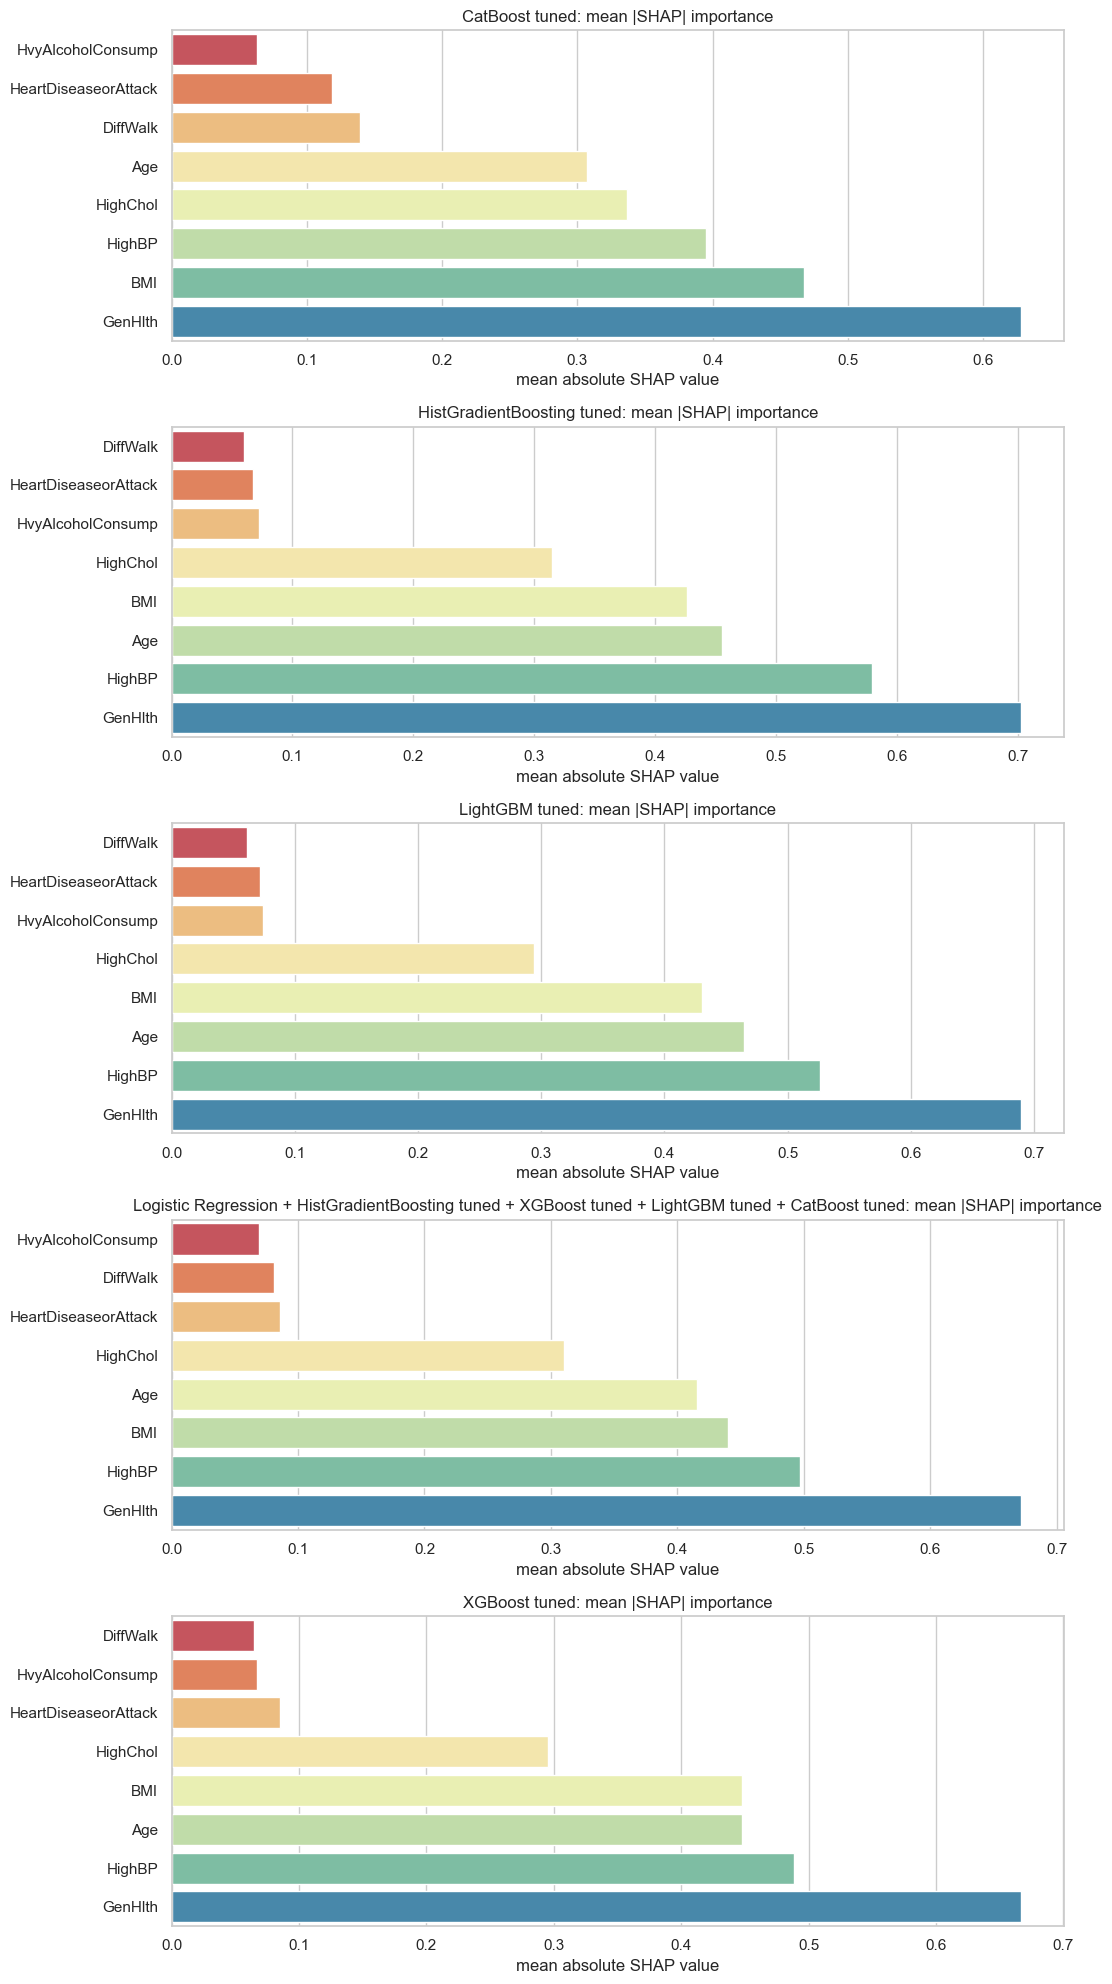

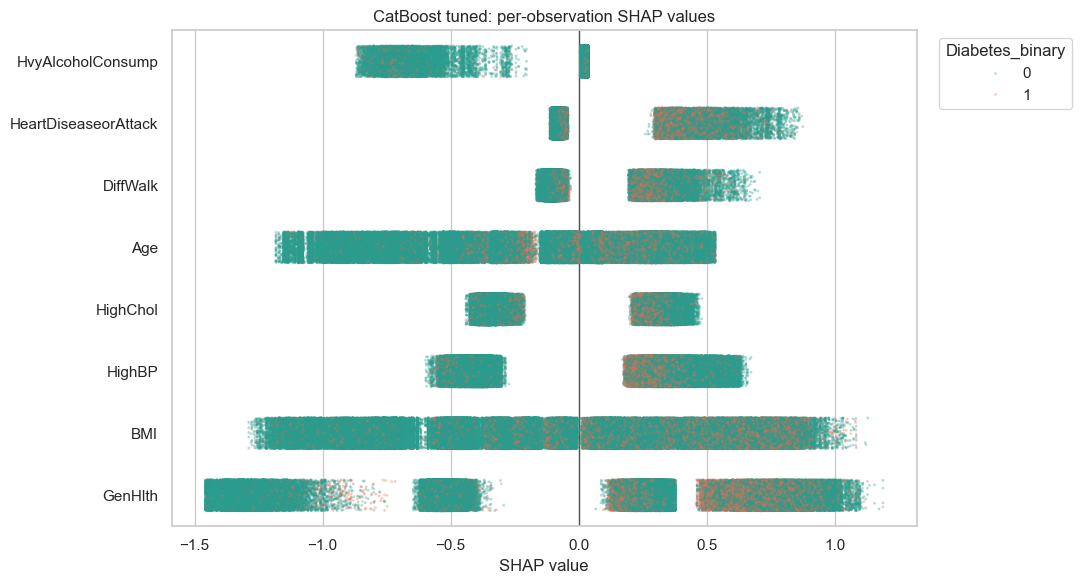

In [ ]:
# SHAP-based feature importance and per-observation SHAP distribution plots.
if "shap_observation_df" not in globals() or shap_observation_df.empty:
    raise ValueError("Run the SHAP cache cell before plotting SHAP feature importance.")

y_train_lookup = pd.Series(y_train.to_numpy(), index=X_train.index, name=target)

shap_feature_importance_df = (
    shap_observation_df
    .assign(abs_shap=lambda df: df["shap_value"].abs())
    .groupby(["model", "shap_kind", "feature"], as_index=False)
    .agg(
        mean_abs_shap=("abs_shap", "mean"),
        mean_shap=("shap_value", "mean"),
    )
    .sort_values(["model", "mean_abs_shap"], ascending=[True, False])
)
shap_feature_importance_df.to_csv(shap_dir / "shap_feature_importance_summary.csv", index=False)
display(shap_feature_importance_df)

models_for_plot = shap_feature_importance_df["model"].drop_duplicates().tolist()
fig, axes = plt.subplots(
    len(models_for_plot),
    1,
    figsize=(11, max(4, 4 * len(models_for_plot))),
    squeeze=False,
)
for ax, model_name in zip(axes.reshape(-1), models_for_plot):
    tmp = (
        shap_feature_importance_df[shap_feature_importance_df["model"].eq(model_name)]
        .nlargest(15, "mean_abs_shap")
        .sort_values("mean_abs_shap")
    )
    sns.barplot(
        data=tmp,
        x="mean_abs_shap",
        y="feature",
        hue="feature",
        palette="Spectral",
        legend=False,
        ax=ax,
    )
    ax.set_title(f"{model_name}: mean |SHAP| importance")
    ax.set_xlabel("mean absolute SHAP value")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

best_shap_model = shap_feature_importance_df.iloc[0]["model"]
best_model_top_features = (
    shap_feature_importance_df[shap_feature_importance_df["model"].eq(best_shap_model)]
    .nlargest(12, "mean_abs_shap")["feature"]
    .tolist()
)
shap_distribution_df = (
    shap_observation_df[
        shap_observation_df["model"].eq(best_shap_model)
        & shap_observation_df["feature"].isin(best_model_top_features)
    ]
    .merge(y_train_lookup.rename("target_value"), left_on="observation_id", right_index=True, how="left")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.stripplot(
    data=shap_distribution_df,
    x="shap_value",
    y="feature",
    hue="target_value",
    order=best_model_top_features[::-1],
    palette=target_palette,
    size=2,
    alpha=0.35,
    jitter=0.25,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1, alpha=0.6)
ax.set_title(f"{best_shap_model}: per-observation SHAP values")
ax.set_xlabel("SHAP value")
ax.set_ylabel("")
ax.legend(title=target, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# L1/Lasso selection on per-observation SHAP values.
# For a binary diabetes target this is L1-regularized logistic regression in SHAP space.
if "shap_observation_df" not in globals() or shap_observation_df.empty:
    raise ValueError("Run the SHAP cache cell before L1 selection on SHAP values.")

exact_shap_df = shap_observation_df[shap_observation_df["shap_kind"].eq("exact")].copy()
if exact_shap_df.empty:
    raise ValueError("No exact SHAP values were found. Use exact model SHAP CSVs, not only approximate blend SHAP.")

shap_lasso_dir = shap_dir
shap_lasso_results = []
shap_lasso_coefficients = []
shap_lasso_selected_features_by_model = {}
lasso_c_grid = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]

# y_train may keep original dataset indices; SHAP cache stores these indices as observation_id.
y_train_lookup = pd.Series(y_train.to_numpy(), index=X_train.index, name=target)

for shap_model_name, model_shap_df in exact_shap_df.groupby("model"):
    shap_matrix = (
        model_shap_df
        .pivot(index="observation_id", columns="feature", values="shap_value")
        .reindex(columns=modeling_features)
        .fillna(0)
        .sort_index()
    )
    y_shap = y_train_lookup.reindex(shap_matrix.index)
    valid_mask = y_shap.notna()
    shap_matrix = shap_matrix.loc[valid_mask]
    y_shap = y_shap.loc[valid_mask].astype(int)

    if y_shap.nunique() < 2:
        continue

    X_lasso_train, X_lasso_val, y_lasso_train, y_lasso_val = train_test_split(
        shap_matrix,
        y_shap,
        test_size=0.25,
        stratify=y_shap,
        random_state=42,
    )

    candidate_rows = []
    candidate_models = {}
    for c_value in lasso_c_grid:
        lasso_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                l1_ratio=1.0,
                solver="saga",
                C=c_value,
                class_weight="balanced",
                max_iter=5000,
                random_state=42,
                n_jobs=-1,
            )),
        ])
        lasso_pipeline.fit(X_lasso_train, y_lasso_train)
        y_val_score = lasso_pipeline.predict_proba(X_lasso_val)[:, 1]

        threshold_scores = []
        for threshold in np.linspace(0.15, 0.85, 71):
            y_val_pred = (y_val_score >= threshold).astype(int)
            threshold_scores.append((
                threshold,
                fbeta_score(y_lasso_val, y_val_pred, beta=metric_beta, zero_division=0),
            ))
        best_threshold, best_fbeta = max(threshold_scores, key=lambda item: item[1])
        y_val_pred = (y_val_score >= best_threshold).astype(int)
        coefficients = lasso_pipeline.named_steps["model"].coef_.ravel()
        n_selected = int((np.abs(coefficients) > 1e-8).sum())

        row = {
            "shap_source_model": shap_model_name,
            "C": c_value,
            "threshold": best_threshold,
            "n_selected_features": n_selected,
            "accuracy": accuracy_score(y_lasso_val, y_val_pred),
            "balanced_accuracy": balanced_accuracy_score(y_lasso_val, y_val_pred),
            "precision": precision_score(y_lasso_val, y_val_pred, zero_division=0),
            "recall": recall_score(y_lasso_val, y_val_pred, zero_division=0),
            "f1": f1_score(y_lasso_val, y_val_pred, zero_division=0),
            "f1_5": best_fbeta,
            "roc_auc": roc_auc_score(y_lasso_val, y_val_score),
            "pr_auc": average_precision_score(y_lasso_val, y_val_score),
        }
        candidate_rows.append(row)
        candidate_models[c_value] = lasso_pipeline

    model_result_df = pd.DataFrame(candidate_rows).sort_values(
        [primary_metric, "pr_auc", "n_selected_features"],
        ascending=[False, False, True],
    )
    best_row = model_result_df.iloc[0]
    best_c = best_row["C"]

    refit_lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            l1_ratio=1.0,
            solver="saga",
            C=best_c,
            class_weight="balanced",
            max_iter=5000,
            random_state=42,
            n_jobs=-1,
        )),
    ])
    refit_lasso.fit(shap_matrix, y_shap)
    coefficients = refit_lasso.named_steps["model"].coef_.ravel()
    coef_df = pd.DataFrame({
        "shap_source_model": shap_model_name,
        "feature": shap_matrix.columns,
        "coefficient": coefficients,
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df["selected"] = coef_df["abs_coefficient"] > 1e-8
    coef_df["C"] = best_c
    coef_df["validation_threshold"] = best_row["threshold"]
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

    shap_lasso_results.extend(candidate_rows)
    shap_lasso_coefficients.append(coef_df)
    shap_lasso_selected_features_by_model[shap_model_name] = coef_df.loc[coef_df["selected"], "feature"].tolist()

shap_lasso_results_df = pd.DataFrame(shap_lasso_results).sort_values(
    [primary_metric, "pr_auc", "n_selected_features"],
    ascending=[False, False, True],
).reset_index(drop=True)
shap_lasso_selection_df = pd.concat(shap_lasso_coefficients, ignore_index=True) if shap_lasso_coefficients else pd.DataFrame()

shap_lasso_results_df.to_csv(shap_lasso_dir / "shap_lasso_validation_results.csv", index=False)
shap_lasso_selection_df.to_csv(shap_lasso_dir / "shap_lasso_feature_selection.csv", index=False)

if shap_lasso_results_df[shap_lasso_results_df['n_selected_features'] < len(modeling_features)].shape[0] > 0:

    display(shap_lasso_results_df)
    display(shap_lasso_selection_df[shap_lasso_selection_df["selected"]].sort_values(["shap_source_model", "abs_coefficient"], ascending=[True, False]))

    best_lasso_source_model = shap_lasso_results_df.iloc[0]["shap_source_model"]
    shap_lasso_features = shap_lasso_selected_features_by_model.get(best_lasso_source_model, [])
    if not shap_lasso_features:
        shap_lasso_features = (
            shap_feature_importance_df[shap_feature_importance_df["model"].eq(best_lasso_source_model)]
            .nlargest(5, "mean_abs_shap")["feature"]
            .tolist()
        )

    print(f"Best SHAP source for L1 selection: {best_lasso_source_model}")
    print(f"Selected features ({len(shap_lasso_features)}): {shap_lasso_features}")
else:
    print("No SHAP Lasso model achieved feature selection")


,shap_source_model,C,threshold,n_selected_features,accuracy,balanced_accuracy,precision,recall,f1,f1_5,roc_auc,pr_auc
0,HistGradientBoosting tuned,0.300,0.560,8,0.763,0.748,0.338,0.727,0.461,0.537,0.833,0.447
1,HistGradientBoosting tuned,0.100,0.560,8,0.763,0.748,0.338,0.727,0.461,0.537,0.833,0.447
2,HistGradientBoosting tuned,3.000,0.560,8,0.763,0.748,0.338,0.727,0.461,0.537,0.833,0.447
3,HistGradientBoosting tuned,1.000,0.560,8,0.763,0.748,0.338,0.727,0.461,0.537,0.833,0.447
4,HistGradientBoosting tuned,0.030,0.560,8,0.763,0.748,0.338,0.727,0.461,0.537,0.833,0.447
5,LightGBM tuned,0.010,0.520,8,0.737,0.752,0.318,0.774,0.450,0.537,0.833,0.444
6,HistGradientBoosting tuned,0.010,0.560,8,0.764,0.748,0.338,0.726,0.461,0.537,0.833,0.447
7,LightGBM tuned,0.030,0.520,8,0.737,0.752,0.317,0.774,0.450,0.536,0.833,0.444
8,LightGBM tuned,3.000,0.520,8,0.737,0.752,0.317,0.774,0.450,0.536,0.833,0.444
9,LightGBM tuned,0.300,0.520,8,0.737,0.752,0.317,0.774,0.450,0.536,0.833,0.444


,shap_source_model,feature,coefficient,abs_coefficient,selected,C,validation_threshold
0,CatBoost tuned,GenHlth,0.750,0.750,True,3.000,0.520
1,CatBoost tuned,BMI,0.580,0.580,True,3.000,0.520
2,CatBoost tuned,Age,0.553,0.553,True,3.000,0.520
3,CatBoost tuned,HighBP,0.369,0.369,True,3.000,0.520
4,CatBoost tuned,HighChol,0.338,0.338,True,3.000,0.520
5,CatBoost tuned,HvyAlcoholConsump,0.178,0.178,True,3.000,0.520
6,CatBoost tuned,HeartDiseaseorAttack,0.160,0.160,True,3.000,0.520
7,CatBoost tuned,DiffWalk,0.139,0.139,True,3.000,0.520
8,HistGradientBoosting tuned,GenHlth,0.844,0.844,True,0.300,0.560
9,HistGradientBoosting tuned,Age,0.596,0.596,True,0.300,0.560


Best SHAP source for L1 selection: HistGradientBoosting tuned
Selected features (8): ['GenHlth', 'Age', 'HighBP', 'BMI', 'HighChol', 'HvyAlcoholConsump', 'HeartDiseaseorAttack', 'DiffWalk']


In [ ]:
# Compare models after removing features that L1-SHAP links to per-observation log loss.
if "loss_lasso_noise_features" not in globals():
    raise ValueError("Run the residual/loss SHAP L1 diagnostic cell first.")

shap_loss_filtered_features = [feature for feature in modeling_features if feature not in loss_lasso_noise_features]
if not shap_loss_filtered_features:
    shap_loss_filtered_features = modeling_features.copy()

filtered_cat_features = [col for col in shap_loss_filtered_features if col != "BMI"]
shap_loss_filtered_models = {
    "Logistic Regression without loss-linked features": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest without loss-linked features": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
    "CatBoost without loss-linked features": CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="F1",
        cat_features=filtered_cat_features,
        one_hot_max_size=32,
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
    ),
}

shap_loss_filtered_results = []
for model_name, fitted in shap_loss_filtered_models.items():
    fitted.fit(X_train[shap_loss_filtered_features], y_train)
    y_pred = fitted.predict(X_test[shap_loss_filtered_features])
    y_score = fitted.predict_proba(X_test[shap_loss_filtered_features])[:, 1] if hasattr(fitted, "predict_proba") else y_pred
    shap_loss_filtered_results.append({
        "model": model_name,
        "model_group": "Loss-filtered",
        "train_rows": len(X_train),
        "n_features": len(shap_loss_filtered_features),
        "removed_features": len(loss_lasso_noise_features),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f1_5": fbeta_score(y_test, y_pred, beta=metric_beta, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    })

shap_loss_filtered_results_df = pd.DataFrame(shap_loss_filtered_results).sort_values(primary_metric, ascending=False).reset_index(drop=True)
shap_loss_filtered_results_df.to_csv(shap_lasso_dir / "shap_loss_filtered_model_results.csv", index=False)
display(shap_loss_filtered_results_df)

loss_filter_comparison_df = pd.concat(
    [
        all_results_df.assign(n_features=len(modeling_features), removed_features=0),
        shap_loss_filtered_results_df,
    ],
    ignore_index=True,
    sort=False,
).sort_values(primary_metric, ascending=False).reset_index(drop=True)
display(loss_filter_comparison_df[["model", "model_group", "n_features", "removed_features", *metric_cols]])

print(f"Remaining features ({len(shap_loss_filtered_features)}): {shap_loss_filtered_features}")
print(f"Removed loss-linked features ({len(loss_lasso_noise_features)}): {loss_lasso_noise_features}")


In [ ]:
# Dimensionality reduction dependencies are imported in the first cell.


In [42]:
embedding_sample_size = 6000
if len(X_model) > embedding_sample_size:
    X_dim_sample, _, y_dim_sample, _ = train_test_split(
        X_model, y_model, train_size=embedding_sample_size, random_state=42, stratify=y_model
    )
else:
    X_dim_sample = X_model.copy()
    y_dim_sample = y_model.copy()

X_dim_scaled = StandardScaler().fit_transform(X_dim_sample)
dim_sample_summary = pd.DataFrame({
    "rows": [len(X_dim_sample)],
    "positive_share": [y_dim_sample.mean()],
    "duplicate_rows_kept": [pd.concat([X_dim_sample, y_dim_sample.rename(target)], axis=1).duplicated().sum()],
})
display(dim_sample_summary)

,rows,positive_share,duplicate_rows_kept
0,6000,0.139,1653


,component,pca_explained_variance_ratio,pca_cumulative_explained_variance,svd_explained_variance_ratio,svd_cumulative_explained_variance
0,1,0.234,0.234,0.234,0.234
1,2,0.125,0.359,0.125,0.359
2,3,0.115,0.474,0.115,0.474
3,4,0.109,0.583,0.109,0.583
4,5,0.106,0.689,0.106,0.689
5,6,0.094,0.784,0.094,0.784
6,7,0.081,0.865,0.081,0.865
7,8,0.074,0.939,0.074,0.939
8,9,0.061,1.000,0.061,1.000


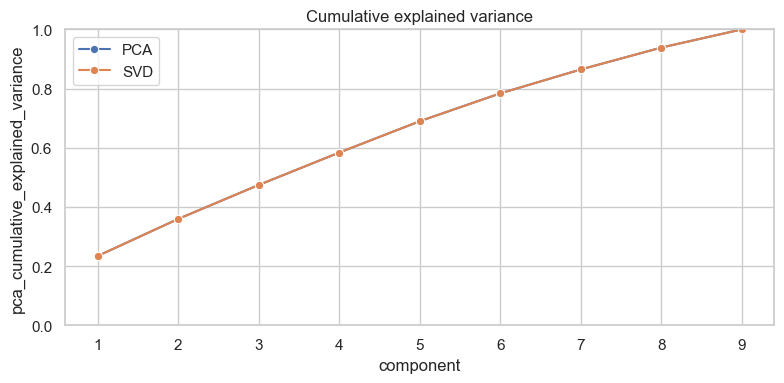

In [43]:
n_components = min(10, X_dim_scaled.shape[1])

pca = PCA(n_components=n_components, random_state=42)
pca_components = pca.fit_transform(X_dim_scaled)

svd = TruncatedSVD(n_components=n_components, random_state=42)
svd_components = svd.fit_transform(X_dim_scaled)

X_dim_nonnegative = MinMaxScaler().fit_transform(X_dim_sample)
nmf = NMF(n_components=n_components, init="nndsvda", max_iter=1000, random_state=42)
nmf_components = nmf.fit_transform(X_dim_nonnegative)

explained_df = pd.DataFrame({
    "component": np.arange(1, n_components + 1),
    "pca_explained_variance_ratio": pca.explained_variance_ratio_,
    "pca_cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    "svd_explained_variance_ratio": svd.explained_variance_ratio_,
    "svd_cumulative_explained_variance": np.cumsum(svd.explained_variance_ratio_),
})
display(explained_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=explained_df, x="component", y="pca_cumulative_explained_variance", marker="o", label="PCA", ax=ax)
sns.lineplot(data=explained_df, x="component", y="svd_cumulative_explained_variance", marker="o", label="SVD", ax=ax)
ax.set_title("Cumulative explained variance")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

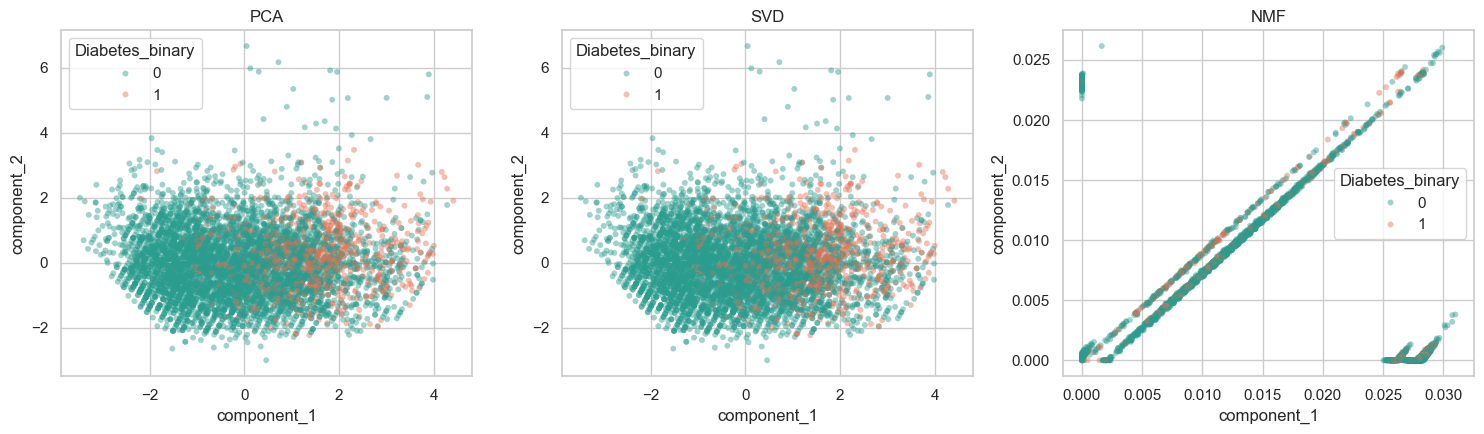

In [44]:
projection_frames = []
for method_name, values in {"PCA": pca_components, "SVD": svd_components, "NMF": nmf_components}.items():
    projection_frames.append(pd.DataFrame({
        "method": method_name,
        "component_1": values[:, 0],
        "component_2": values[:, 1],
        target: y_dim_sample.to_numpy(),
    }))
projection_df = pd.concat(projection_frames, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, method_name in zip(axes, ["PCA", "SVD", "NMF"]):
    tmp = projection_df[projection_df["method"] == method_name]
    sns.scatterplot(data=tmp, x="component_1", y="component_2", hue=target, palette=target_palette, alpha=0.45, s=18, linewidth=0, ax=ax)
    ax.set_title(method_name)
plt.tight_layout()
plt.show()

,PC1,PC2
HighBP,0.504,0.013
GenHlth,0.429,0.259
HighChol,0.412,-0.107
Age,0.392,-0.508
HeartDiseaseorAttack,0.376,-0.059
BMI,0.246,0.644
CholCheck,0.171,-0.232
Sex,0.072,0.434
HvyAlcoholConsump,-0.037,0.054


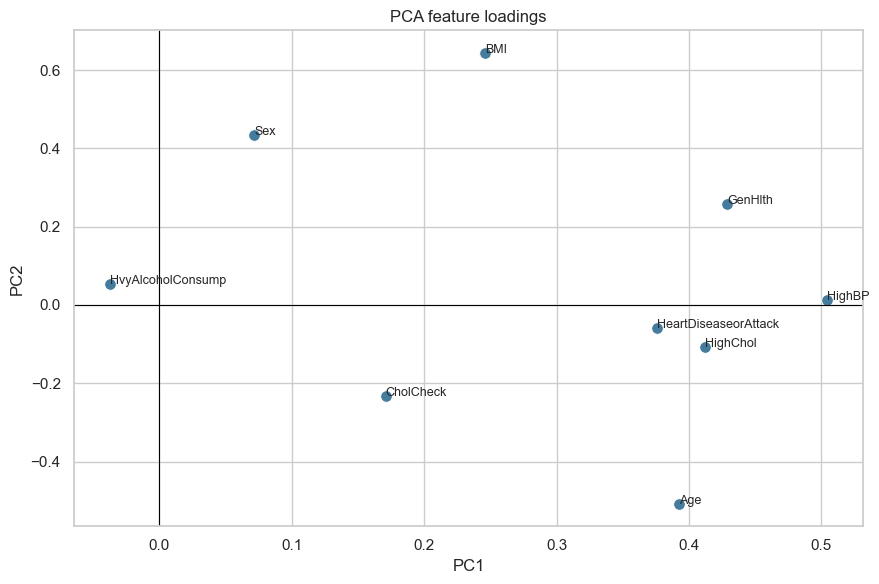

In [45]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=modeling_features,
    columns=[f"PC{i}" for i in range(1, n_components + 1)],
)
display(pca_loadings[["PC1", "PC2"]].sort_values("PC1", key=lambda s: s.abs(), ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
loadings_plot = pca_loadings[["PC1", "PC2"]].reset_index().rename(columns={"index": "feature"})
sns.scatterplot(data=loadings_plot, x="PC1", y="PC2", color="#457b9d", s=70, ax=ax)
for _, row in loadings_plot.iterrows():
    ax.text(row["PC1"], row["PC2"], row["feature"], fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("PCA feature loadings")
plt.tight_layout()
plt.show()

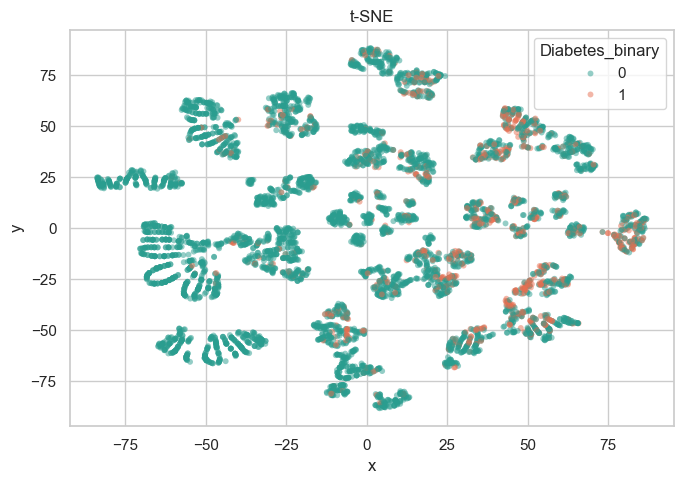

In [46]:
embedding_base = pca_components[:, :min(10, pca_components.shape[1])]

tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", max_iter=1000, random_state=42)
tsne_embedding = tsne.fit_transform(embedding_base)

embedding_frames = [pd.DataFrame({
    "method": "t-SNE",
    "x": tsne_embedding[:, 0],
    "y": tsne_embedding[:, 1],
    target: y_dim_sample.to_numpy(),
})]


embedding_df = pd.concat(embedding_frames, ignore_index=True)
methods = embedding_df["method"].unique()
fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 5), squeeze=False)
for ax, method_name in zip(axes.reshape(-1), methods):
    tmp = embedding_df[embedding_df["method"] == method_name]
    sns.scatterplot(data=tmp, x="x", y="y", hue=target, palette=target_palette, alpha=0.5, s=18, linewidth=0, ax=ax)
    ax.set_title(method_name)
plt.tight_layout()
plt.show()

In [ ]:
# Train/test evaluation on dimensionality-reduced feature spaces.
# Transformers are fit on train only, then applied to test to avoid leakage.
max_reduction_components = min(10, X_train.shape[1])
reduction_component_grid = sorted({2, 3, 5, max_reduction_components})
reduction_component_grid = [n for n in reduction_component_grid if 1 < n <= X_train.shape[1]]

reduced_model_templates = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Naive Bayes": GaussianNB(),
    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=180,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42,
    ),
}


def build_reduced_features(method_name, n_components):
    if method_name == "PCA":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        reducer = PCA(n_components=n_components, random_state=42)
        return reducer.fit_transform(X_train_scaled), reducer.transform(X_test_scaled), reducer

    if method_name == "SVD":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        reducer = TruncatedSVD(n_components=n_components, random_state=42)
        return reducer.fit_transform(X_train_scaled), reducer.transform(X_test_scaled), reducer

    if method_name == "NMF":
        scaler = MinMaxScaler()
        X_train_nonnegative = scaler.fit_transform(X_train)
        X_test_nonnegative = scaler.transform(X_test)
        reducer = NMF(n_components=n_components, init="nndsvda", max_iter=1000, random_state=42)
        return reducer.fit_transform(X_train_nonnegative), reducer.transform(X_test_nonnegative), reducer

    raise ValueError(f"Unknown reduction method: {method_name}")


reduced_results = []
reduced_fitted_models = {}

for reduction_method in ["PCA", "SVD", "NMF"]:
    for n_components in reduction_component_grid:
        X_train_reduced, X_test_reduced, reducer = build_reduced_features(reduction_method, n_components)
        for model_name, estimator in reduced_model_templates.items():
            fitted = clone(estimator)
            fitted.fit(X_train_reduced, y_train)
            y_pred = fitted.predict(X_test_reduced)
            if hasattr(fitted, "predict_proba"):
                y_score = fitted.predict_proba(X_test_reduced)[:, 1]
            elif hasattr(fitted, "decision_function"):
                y_score = fitted.decision_function(X_test_reduced)
            else:
                y_score = y_pred

            experiment_name = f"{reduction_method}-{n_components} + {model_name}"
            reduced_fitted_models[experiment_name] = fitted
            reduced_results.append({
                "reduction": reduction_method,
                "n_components": n_components,
                "model": model_name,
                "experiment": experiment_name,
                "accuracy": accuracy_score(y_test, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "f1_5": fbeta_score(y_test, y_pred, beta=metric_beta, zero_division=0),
                "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
                "roc_auc": roc_auc_score(y_test, y_score),
                "pr_auc": average_precision_score(y_test, y_score),
            })

reduced_results_df = (
    pd.DataFrame(reduced_results)
    .sort_values(["f1_5", "pr_auc", "recall"], ascending=False)
    .reset_index(drop=True)
)

display(reduced_results_df.head(20))

In [ ]:
reduced_results_df

In [43]:
# Compare reduced-space models with the best available non-reduced candidates.
comparison_metric = primary_metric

baseline_tables = []
if "all_results_df" in globals():
    baseline_tables.append(all_results_df.assign(source="Original selected features and blends"))
if "shap_lasso_reduced_results_df" in globals():
    baseline_tables.append(shap_lasso_reduced_results_df.assign(source="SHAP-L1 selected original features"))
if "shap_loss_filtered_results_df" in globals():
    baseline_tables.append(shap_loss_filtered_results_df.assign(source="Loss-filtered original features"))

baseline_results_df = pd.concat(baseline_tables, ignore_index=True, sort=False)
best_original = baseline_results_df.sort_values([comparison_metric, "pr_auc", "recall"], ascending=False).iloc[0]
best_reduced = reduced_results_df.sort_values([comparison_metric, "pr_auc", "recall"], ascending=False).iloc[0]

reduction_summary_df = (
    reduced_results_df
    .groupby(["reduction", "n_components"], as_index=False)
    .agg(
        best_pr_auc=("pr_auc", "max"),
        best_roc_auc=("roc_auc", "max"),
        best_f1=("f1", "max"),
        best_f1_5=("f1_5", "max"),
        best_f2=("f2", "max"),
        best_recall=("recall", "max"),
    )
    .sort_values("best_f1_5", ascending=False)
)
display(reduction_summary_df)

best_comparison_df = pd.DataFrame([
    {
        "feature_space": best_original["source"],
        "model": best_original["model"],
        "pr_auc": best_original["pr_auc"],
        "roc_auc": best_original["roc_auc"],
        "f1": best_original["f1"],
        "f1_5": best_original["f1_5"],
        "recall": best_original["recall"],
    },
    {
        "feature_space": f"{best_reduced['reduction']} ({int(best_reduced['n_components'])} components)",
        "model": best_reduced["model"],
        "pr_auc": best_reduced["pr_auc"],
        "roc_auc": best_reduced["roc_auc"],
        "f1": best_reduced["f1"],
        "f1_5": best_reduced["f1_5"],
        "recall": best_reduced["recall"],
    },
])
display(best_comparison_df)

plot_df = reduced_results_df.copy()
plot_df["method_components"] = plot_df["reduction"] + "-" + plot_df["n_components"].astype(str)
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_df, x="method_components", y="f1_5", hue="model", palette="tab20", ax=ax)
ax.axhline(best_original["f1_5"], color="black", linestyle="--", linewidth=1, label="best non-reduced F1.5")
ax.set_title("F1.5 on dimensionality-reduced features")
ax.set_xlabel("reduction method and number of components")
ax.set_ylabel("F1.5")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


NameError: name 'reduced_results_df' is not defined

In [ ]:
# Final decision about dimensionality reduction and the production candidate model.
comparison_metric = primary_metric
min_meaningful_improvement = 0.005

metric_delta = best_reduced[comparison_metric] - best_original[comparison_metric]
pr_auc_delta = best_reduced["pr_auc"] - best_original["pr_auc"]
recall_delta = best_reduced["recall"] - best_original["recall"]

if metric_delta >= min_meaningful_improvement:
    final_model_name = best_reduced["experiment"]
    final_feature_space = f"{best_reduced['reduction']} ({int(best_reduced['n_components'])} components)"
    final_model_score = best_reduced[comparison_metric]
    final_model_object = reduced_fitted_models.get(best_reduced["experiment"])
    final_model_artifact_type = "fitted estimator on reduced features"
    final_model_reason = (
        f"The reduced representation improved {comparison_metric} by {metric_delta:+.4f}, "
        "which is above the practical improvement threshold."
    )
else:
    final_model_name = best_original["model"]
    final_feature_space = best_original["source"]
    final_model_score = best_original[comparison_metric]
    final_model_artifact_type = "fitted estimator or blend recipe on selected original features"
    final_model_reason = (
        f"Dimensionality reduction changed {comparison_metric} by only {metric_delta:+.4f}; "
        "the best non-reduced candidate is preferred."
    )
    if final_model_name in fitted_models:
        final_model_object = fitted_models[final_model_name]
    elif final_model_name in tuned_advanced_fitted_models:
        final_model_object = tuned_advanced_fitted_models[final_model_name]
    elif final_model_name in blend_predictions:
        final_model_object = blend_predictions[final_model_name]
        final_model_artifact_type = "blend recipe with component names, threshold, and cached scores"
    else:
        final_model_object = None

final_model_candidate = {
    "model": final_model_name,
    "feature_space": final_feature_space,
    "artifact_type": final_model_artifact_type,
    "object": final_model_object,
}

final_model_summary = pd.DataFrame([{
    "final_model": final_model_name,
    "feature_space": final_feature_space,
    "artifact_type": final_model_artifact_type,
    "selection_metric": comparison_metric,
    "selection_metric_value": final_model_score,
    "delta_vs_best_non_reduced": metric_delta,
    "pr_auc_delta": pr_auc_delta,
    "recall_delta": recall_delta,
    "reason": final_model_reason,
}])

display(final_model_summary)
print(f"Best non-reduced candidate: {best_original['model']} | {comparison_metric}={best_original[comparison_metric]:.4f}, PR AUC={best_original['pr_auc']:.4f}, recall={best_original['recall']:.4f}")
print(f"Best reduced-space candidate: {best_reduced['experiment']} | {comparison_metric}={best_reduced[comparison_metric]:.4f}, PR AUC={best_reduced['pr_auc']:.4f}, recall={best_reduced['recall']:.4f}")
print(f"Final model: {final_model_name} on {final_feature_space}")
print(final_model_reason)
